# Phase 4: Industry–Occupation Mix and Exposure Impact

This notebook summarizes industry–occupation exposure mix and explores exposure vs cumulative demand growth.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_root(start: Path) -> Path:
    here = start.resolve()
    for p in [here] + list(here.parents):
        if (p / 'Results Datasets' / 'final_analysis_dataset.parquet').exists():
            return p
    raise FileNotFoundError('Could not find Results Datasets/final_analysis_dataset.parquet')

ROOT = find_root(Path.cwd())
DATA_PATH = ROOT / 'Results Datasets' / 'final_analysis_dataset.parquet'
OUT_BASE = ROOT / 'Results Datasets' / 'analysis' / 'phase4_exposure_impact'
OUT_TABLES = OUT_BASE / 'tables'
OUT_VIS = OUT_BASE / 'visuals'
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_VIS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df = df[(df['adve_time_year'] >= 2010) & (df['adve_time_year'] <= 2024)].copy()

WEIGHT = 'srvy_wght_tru2'
occ_exp_col = 'occupation_exposure'
ind_exp_col = 'industry_exposure_weighted'

def _finite_for_plot(df_in, xcol, ycol, y_positive=False):
    tmp = df_in.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol, ycol])
    if y_positive:
        tmp = tmp[tmp[ycol] > 0]
    return tmp

def _wmean(series, weights):
    if series.empty:
        return np.nan
    return np.average(series, weights=weights)

def weighted_quantile(values, weights, q):
    v = np.asarray(values)
    w = np.asarray(weights)
    m = np.isfinite(v) & np.isfinite(w)
    if not m.any():
        return np.nan
    v = v[m]
    w = w[m]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    cum = np.cumsum(w)
    cutoff = q * cum[-1]
    return v[np.searchsorted(cum, cutoff)]

occ_p80 = weighted_quantile(df[occ_exp_col], df[WEIGHT], 0.80)

# Label fallbacks if missing
if 'comp_indu_noga_label' not in df.columns and 'comp_indu_noga' in df.columns:
    df['comp_indu_noga_label'] = df['comp_indu_noga'].astype(str)
if 'occu_isco2_label' not in df.columns and 'occu_isco_2008' in df.columns:
    raw = df['occu_isco_2008'].astype(str).str.strip()
    raw = raw.str.split('.', n=1).str[0]
    df['occu_isco2_label'] = raw.str.zfill(4).str[:2]

noga_label_col = 'industry_section_label' if 'industry_section_label' in df.columns else ('noga_section_label' if 'noga_section_label' in df.columns else None)
isco2_label_col = 'occu_isco2_label' if 'occu_isco2_label' in df.columns else None


## 4.1 Industry–occupation exposure mix (comp_indu_noga)


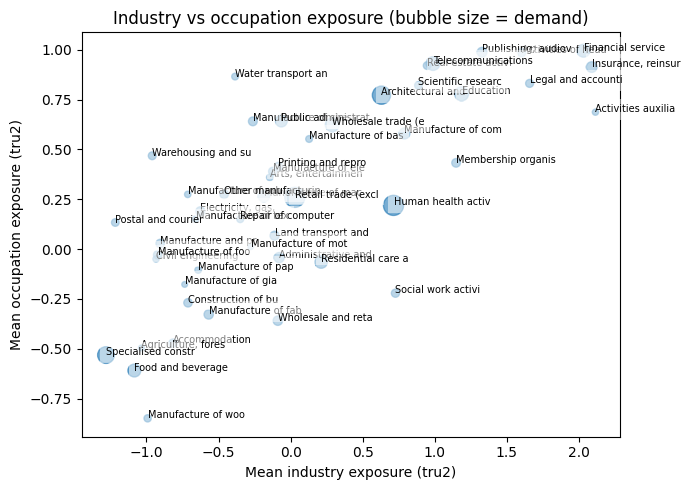

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble.png
Pearson: 0.7389407993948134
Spearman: 0.7388775510204082
Weighted Pearson: 0.8005239884029244
Demand vs ind exposure Pearson: 0.18374627860609496
Demand vs ind exposure Spearman: 0.32357142857142857
Demand vs ind exposure Weighted Pearson: 0.10154224398132866
Demand vs occ exposure Pearson: 0.09449938433922589
Demand vs occ exposure Spearman: 0.15775510204081633
Demand vs occ exposure Weighted Pearson: 0.0034753956328008526


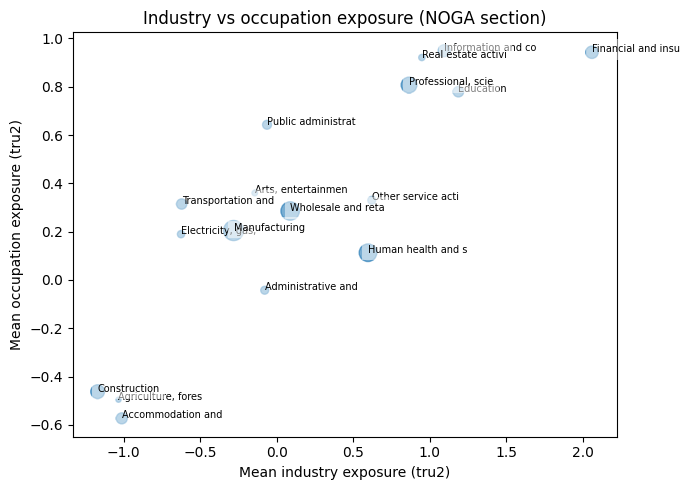

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_noga_section.png
noga_section Pearson: 0.8533950670974755
noga_section Spearman: 0.8406862745098039
noga_section Weighted Pearson: 0.844867571648986
noga_section Demand vs ind exposure Pearson: 0.09431413601243581
noga_section Demand vs ind exposure Spearman: 0.18872549019607843
noga_section Demand vs ind exposure Weighted Pearson: -0.12643440831797798
noga_section Demand vs occ exposure Pearson: 0.004620884549593317
noga_section Demand vs occ exposure Spearman: 0.03676470588235294
noga_section Demand vs occ exposure Weighted Pearson: -0.1389746663561954


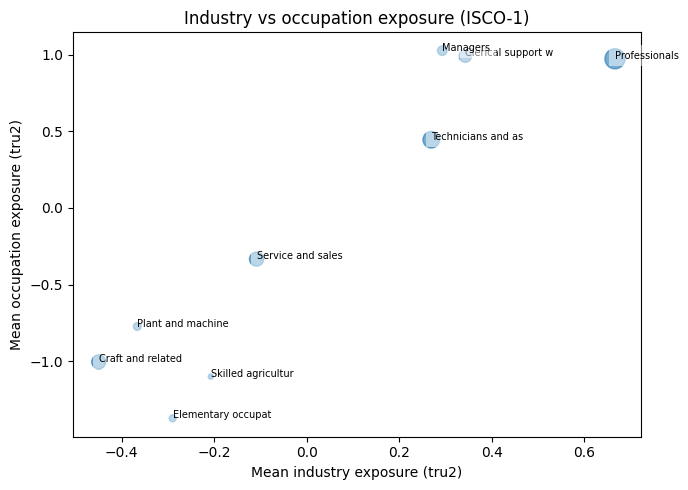

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_isco1.png
isco1 Pearson: 0.9235169055044401
isco1 Spearman: 0.8
isco1 Weighted Pearson: 0.9468149532509863
isco1 Demand vs ind exposure Pearson: 0.6523070155211343
isco1 Demand vs ind exposure Spearman: 0.48333333333333334
isco1 Demand vs ind exposure Weighted Pearson: 0.7310903769850251
isco1 Demand vs occ exposure Pearson: 0.5593671198825327
isco1 Demand vs occ exposure Spearman: 0.5166666666666667
isco1 Demand vs occ exposure Weighted Pearson: 0.5429573905602479


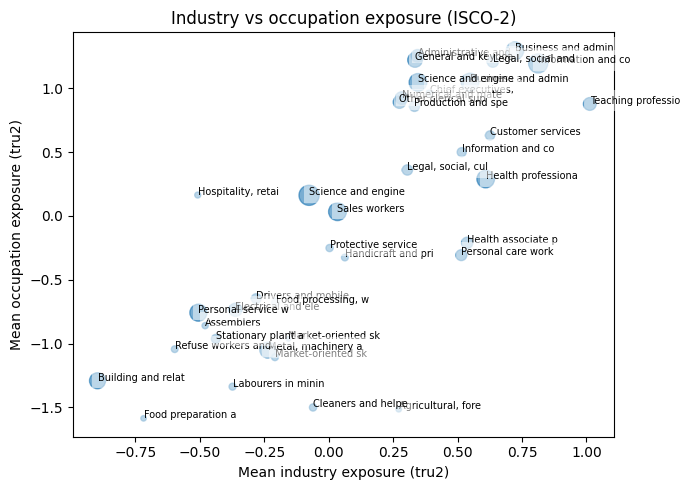

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_ind_vs_occ_exposure_bubble_isco2.png
isco2 Pearson: 0.7685607779540443
isco2 Spearman: 0.7667140825035562
isco2 Weighted Pearson: 0.8342674119826401
isco2 Demand vs ind exposure Pearson: 0.283726729211306
isco2 Demand vs ind exposure Spearman: 0.422475106685633
isco2 Demand vs ind exposure Weighted Pearson: 0.09480149064344344
isco2 Demand vs occ exposure Pearson: 0.4333983223844126
isco2 Demand vs occ exposure Spearman: 0.5410876463508042
isco2 Demand vs occ exposure Weighted Pearson: 0.2239060339164724


In [3]:
# Industry-level mix (comp_indu_noga)
ind_mix = df.groupby(df['comp_indu_noga_label'].fillna('Unknown')).apply(
    lambda g: pd.Series({
        'demand_total_tru2': g[WEIGHT].sum(),
        'mean_ind_exp': np.average(g[ind_exp_col].dropna(), weights=g.loc[g[ind_exp_col].notna(), WEIGHT]) if g[ind_exp_col].notna().any() else np.nan,
        'mean_occ_exp': np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(), WEIGHT]) if g[occ_exp_col].notna().any() else np.nan,
        'share_high_occ_p80': (
            g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), WEIGHT].sum() /
            g.loc[g[occ_exp_col].notna(), WEIGHT].sum()
        ) if g[occ_exp_col].notna().any() else np.nan,
        'coverage': g.loc[g[occ_exp_col].notna(), WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan,
    })
).reset_index().rename(columns={'comp_indu_noga_label':'indu_label'})

ind_mix.to_csv(OUT_TABLES / 'table_ind_occ_mix.csv', index=False)

plt.figure(figsize=(7,5))
ind_mix_plot = _finite_for_plot(ind_mix, 'mean_ind_exp', 'mean_occ_exp', y_positive=False)
ind_mix_plot = ind_mix_plot[ind_mix_plot['demand_total_tru2'] > 0]
plt.scatter(
    ind_mix_plot['mean_ind_exp'],
    ind_mix_plot['mean_occ_exp'],
    s=(ind_mix_plot['demand_total_tru2'] / ind_mix_plot['demand_total_tru2'].max())*200 + 10,
    alpha=0.6
)
for _, row in ind_mix_plot.iterrows():
    plt.text(row['mean_ind_exp'], row['mean_occ_exp'], str(row['indu_label'])[:18], fontsize=7,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
plt.xlabel('Mean industry exposure (tru2)')
plt.ylabel('Mean occupation exposure (tru2)')
plt.title('Industry vs occupation exposure (bubble size = demand)')
plt.tight_layout()
fig_path = OUT_VIS / 'fig_ind_vs_occ_exposure_bubble.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)

valid = ind_mix.dropna(subset=['mean_ind_exp', 'mean_occ_exp'])
pearson = valid[['mean_ind_exp','mean_occ_exp']].corr().iloc[0,1]
spearman = valid[['mean_ind_exp','mean_occ_exp']].corr(method='spearman').iloc[0,1]
w = valid['demand_total_tru2'].to_numpy()
xi = valid['mean_ind_exp'].to_numpy()
yi = valid['mean_occ_exp'].to_numpy()
wmx = np.average(xi, weights=w)
wmy = np.average(yi, weights=w)
wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

print('Pearson:', pearson)
print('Spearman:', spearman)
print('Weighted Pearson:', weighted_pearson)

valid_d = valid.dropna(subset=['demand_total_tru2', 'mean_ind_exp', 'mean_occ_exp'])
if not valid_d.empty:
    pearson_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr().iloc[0,1]
    spearman_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr(method='spearman').iloc[0,1]
    pearson_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr().iloc[0,1]
    spearman_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr(method='spearman').iloc[0,1]

    w_d = valid_d['demand_total_tru2'].to_numpy()
    xd = valid_d['demand_total_tru2'].to_numpy()
    yi = valid_d['mean_ind_exp'].to_numpy()
    yo = valid_d['mean_occ_exp'].to_numpy()
    wmx = (xd * w_d).sum() / w_d.sum()
    wmy_i = (yi * w_d).sum() / w_d.sum()
    wmy_o = (yo * w_d).sum() / w_d.sum()
    wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
    wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
    wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
    wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
    weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
    weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

    print('Demand vs ind exposure Pearson:', pearson_d_ind)
    print('Demand vs ind exposure Spearman:', spearman_d_ind)
    print('Demand vs ind exposure Weighted Pearson:', weighted_pearson_d_ind)
    print('Demand vs occ exposure Pearson:', pearson_d_occ)
    print('Demand vs occ exposure Spearman:', spearman_d_occ)
    print('Demand vs occ exposure Weighted Pearson:', weighted_pearson_d_occ)

# === Industry-level mix: NOGA section + ISCO-1/2 ===
def industry_mix_by(group_label_col, exp_col, out_suffix, title):
    if group_label_col is None or group_label_col not in df.columns:
        print(f'Skipping {out_suffix}: {group_label_col} not in dataset')
        return
    mix = df.groupby(df[group_label_col].fillna('Unknown')).apply(
        lambda g: pd.Series({
            'demand_total_tru2': g[WEIGHT].sum(),
            'mean_ind_exp': np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT]) if g[exp_col].notna().any() else np.nan,
            'mean_occ_exp': np.average(g[occ_exp_col].dropna(), weights=g.loc[g[occ_exp_col].notna(), WEIGHT]) if g[occ_exp_col].notna().any() else np.nan,
            'share_high_occ_p80': (
                g.loc[g[occ_exp_col].notna() & (g[occ_exp_col] >= occ_p80), WEIGHT].sum() /
                g.loc[g[occ_exp_col].notna(), WEIGHT].sum()
            ) if g[occ_exp_col].notna().any() else np.nan,
            'coverage': g.loc[g[occ_exp_col].notna(), WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan,
        })
    ).reset_index().rename(columns={group_label_col: 'indu_label'})

    mix.to_csv(OUT_TABLES / f'table_ind_occ_mix_{out_suffix}.csv', index=False)

    plt.figure(figsize=(7,5))
    mix_plot = _finite_for_plot(mix, 'mean_ind_exp', 'mean_occ_exp', y_positive=False)
    mix_plot = mix_plot[mix_plot['demand_total_tru2'] > 0]
    plt.scatter(mix_plot['mean_ind_exp'], mix_plot['mean_occ_exp'],
                s=(mix_plot['demand_total_tru2'] / mix_plot['demand_total_tru2'].max())*200+10,
                alpha=0.6)
    for _, row in mix_plot.iterrows():
        plt.text(row['mean_ind_exp'], row['mean_occ_exp'], str(row['indu_label'])[:18], fontsize=7,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    plt.xlabel('Mean industry exposure (tru2)')
    plt.ylabel('Mean occupation exposure (tru2)')
    plt.title(title)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ind_vs_occ_exposure_bubble_{out_suffix}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    valid = mix.dropna(subset=['mean_ind_exp', 'mean_occ_exp'])
    pearson = valid[['mean_ind_exp','mean_occ_exp']].corr().iloc[0,1]
    spearman = valid[['mean_ind_exp','mean_occ_exp']].corr(method='spearman').iloc[0,1]
    w = valid['demand_total_tru2'].to_numpy()
    xi = valid['mean_ind_exp'].to_numpy()
    yi = valid['mean_occ_exp'].to_numpy()
    wmx = np.average(xi, weights=w)
    wmy = np.average(yi, weights=w)
    wcov = np.average((xi-wmx)*(yi-wmy), weights=w)
    wsx = np.sqrt(np.average((xi-wmx)**2, weights=w))
    wsy = np.sqrt(np.average((yi-wmy)**2, weights=w))
    weighted_pearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan

    print(f'{out_suffix} Pearson:', pearson)
    print(f'{out_suffix} Spearman:', spearman)
    print(f'{out_suffix} Weighted Pearson:', weighted_pearson)

    valid_d = valid.dropna(subset=['demand_total_tru2', 'mean_ind_exp', 'mean_occ_exp'])
    if not valid_d.empty:
        pearson_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr().iloc[0,1]
        spearman_d_ind = valid_d[['demand_total_tru2','mean_ind_exp']].corr(method='spearman').iloc[0,1]
        pearson_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr().iloc[0,1]
        spearman_d_occ = valid_d[['demand_total_tru2','mean_occ_exp']].corr(method='spearman').iloc[0,1]

        w_d = valid_d['demand_total_tru2'].to_numpy()
        xd = valid_d['demand_total_tru2'].to_numpy()
        yi = valid_d['mean_ind_exp'].to_numpy()
        yo = valid_d['mean_occ_exp'].to_numpy()
        wmx = (xd * w_d).sum() / w_d.sum()
        wmy_i = (yi * w_d).sum() / w_d.sum()
        wmy_o = (yo * w_d).sum() / w_d.sum()
        wcov_i = (w_d * (xd - wmx) * (yi - wmy_i)).sum() / w_d.sum()
        wcov_o = (w_d * (xd - wmx) * (yo - wmy_o)).sum() / w_d.sum()
        wsx = ((w_d * (xd - wmx) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_i = ((w_d * (yi - wmy_i) ** 2).sum() / w_d.sum()) ** 0.5
        wsy_o = ((w_d * (yo - wmy_o) ** 2).sum() / w_d.sum()) ** 0.5
        weighted_pearson_d_ind = wcov_i / (wsx * wsy_i) if wsx>0 and wsy_i>0 else np.nan
        weighted_pearson_d_occ = wcov_o / (wsx * wsy_o) if wsx>0 and wsy_o>0 else np.nan

        print(f'{out_suffix} Demand vs ind exposure Pearson:', pearson_d_ind)
        print(f'{out_suffix} Demand vs ind exposure Spearman:', spearman_d_ind)
        print(f'{out_suffix} Demand vs ind exposure Weighted Pearson:', weighted_pearson_d_ind)
        print(f'{out_suffix} Demand vs occ exposure Pearson:', pearson_d_occ)
        print(f'{out_suffix} Demand vs occ exposure Spearman:', spearman_d_occ)
        print(f'{out_suffix} Demand vs occ exposure Weighted Pearson:', weighted_pearson_d_occ)

noga_label_col = 'industry_section_label' if 'industry_section_label' in df.columns else 'noga_section_label'
industry_mix_by(noga_label_col, ind_exp_col, 'noga_section', 'Industry vs occupation exposure (NOGA section)')
industry_mix_by('occu_isco1_label', ind_exp_col, 'isco1', 'Industry vs occupation exposure (ISCO-1)')
industry_mix_by('occu_isco2_label', ind_exp_col, 'isco2', 'Industry vs occupation exposure (ISCO-2)')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


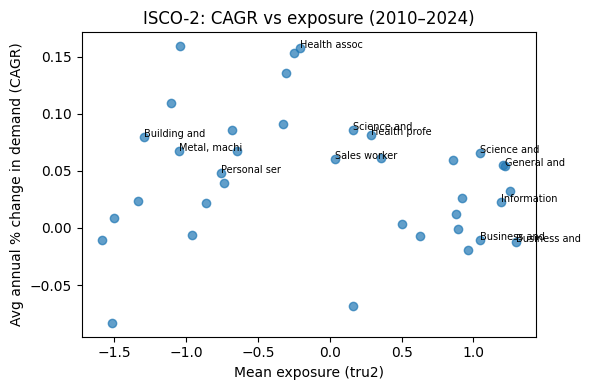

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_vs_exposure_isco2.png
ISCO-2: CAGR vs exposure (2010–2024) Pearson: -0.1395045785688686
ISCO-2: CAGR vs exposure (2010–2024) Spearman: -0.18255097202465623


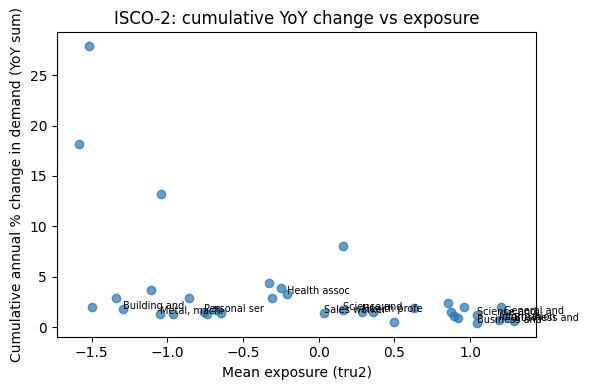

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_vs_exposure_isco2.png
ISCO-2: cumulative YoY change vs exposure Pearson: -0.4706696839697325
ISCO-2: cumulative YoY change vs exposure Spearman: -0.5806069227121858


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


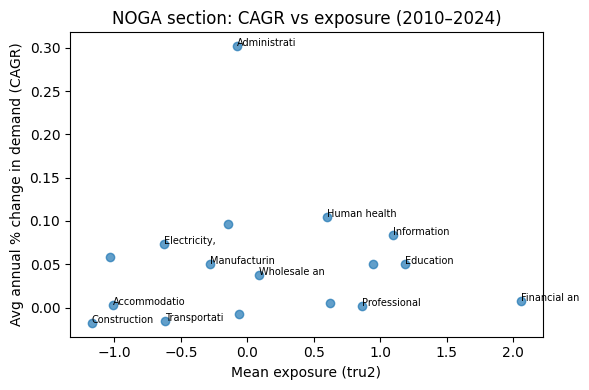

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_vs_exposure_noga_section.png
NOGA section: CAGR vs exposure (2010–2024) Pearson: 0.02606184083838617
NOGA section: CAGR vs exposure (2010–2024) Spearman: 0.12745098039215685


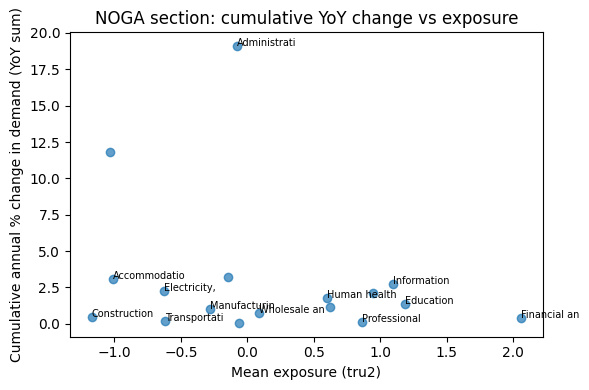

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_vs_exposure_noga_section.png
NOGA section: cumulative YoY change vs exposure Pearson: -0.24451107117299675
NOGA section: cumulative YoY change vs exposure Spearman: -0.22058823529411764


In [4]:
# --- Exposure impact: demand change vs exposure (ISCO-2 and NOGA section)
# Metrics:
# - CAGR: ((last/first)^(1/years) - 1)
# - cumulative_yoy: sum of year-over-year % changes
# - period changes: avg(2010–14) -> avg(2020–24) and avg(2015–19) -> avg(2020–24)

PERIODS = [(2010, 2014, '2010-2014'), (2015, 2019, '2015-2019'), (2020, 2024, '2020-2024')]

def _period_label(y):
    for a,b,lbl in PERIODS:
        if a <= y <= b:
            return lbl
    return None

def _group_demand_series(df, group_col):
    return (
        df.groupby([group_col, 'adve_time_year'])[WEIGHT]
          .sum()
          .reset_index()
    )

def _group_mean_exposure(df, group_col, exp_col):
    return (
        df.groupby(group_col)
          .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])
                 if g[exp_col].notna().any() else np.nan)
          .rename('mean_exposure')
    )

def _compute_change_metrics(df, group_col, exp_col, out_tag):
    # years
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    series = _group_demand_series(df, group_col)
    exp = _group_mean_exposure(df, group_col, exp_col)

    # first/last demand
    first = series[series['adve_time_year'] == y0].set_index(group_col)[WEIGHT]
    last = series[series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    out = pd.DataFrame({'mean_exposure': exp, 'demand_first': first, 'demand_last': last}).reset_index().rename(columns={group_col:'group'})
    out = out.dropna(subset=['demand_first','demand_last','mean_exposure'])
    out = out[(out['demand_first'] > 0) & (out['demand_last'] > 0)]

    # CAGR
    out['cagr'] = (out['demand_last'] / out['demand_first']) ** (1 / n_years) - 1

    # cumulative YoY change
    yoy = series.copy()
    yoy['prev'] = yoy.groupby(group_col)[WEIGHT].shift(1)
    yoy['yoy'] = yoy[WEIGHT] / yoy['prev'] - 1
    cum_yoy = yoy.groupby(group_col)['yoy'].sum().rename('cumulative_yoy')
    out = out.merge(cum_yoy, left_on='group', right_index=True, how='left')

    # period averages
    series['period'] = series['adve_time_year'].map(_period_label)
    period_avg = (
        series.dropna(subset=['period'])
              .groupby([group_col, 'period'])[WEIGHT]
              .mean()
              .unstack()
    )
    out = out.merge(period_avg, left_on='group', right_index=True, how='left')
    if '2010-2014' in out.columns and '2020-2024' in out.columns:
        out['pct_change_2010_2014_to_2020_2024'] = (out['2020-2024'] / out['2010-2014']) - 1
    if '2015-2019' in out.columns and '2020-2024' in out.columns:
        out['pct_change_2015_2019_to_2020_2024'] = (out['2020-2024'] / out['2015-2019']) - 1
    if all(col in out.columns for col in ['2010-2014','2015-2019','2020-2024']):
        out['avg_period_demand'] = out[['2010-2014','2015-2019','2020-2024']].mean(axis=1)

    out.to_csv(OUT_TABLES / f'table_demand_change_metrics_{out_tag}.csv', index=False)
    return out


def _scatter_with_corr(df, x_col, y_col, label, out_tag, y_label):
    tmp = df.dropna(subset=[x_col, y_col])
    if tmp.empty:
        print(f"Skipping {out_tag}: no data")
        return
    plt.figure(figsize=(6,4))
    plt.scatter(tmp[x_col], tmp[y_col], alpha=0.7)
    for _, row in tmp.nlargest(12, 'demand_last').iterrows():
        plt.text(row[x_col], row[y_col], str(row['group'])[:12], fontsize=7)
    plt.xlabel('Mean exposure (tru2)')
    plt.ylabel(y_label)
    plt.title(label)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_{out_tag}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    pearson = tmp[[x_col, y_col]].corr().iloc[0,1]
    spearman = tmp[[x_col, y_col]].corr(method='spearman').iloc[0,1]
    print(f"{label} Pearson:", pearson)
    print(f"{label} Spearman:", spearman)


# ISCO-2 (occupation exposure)
if 'occu_isco2_label' in df.columns:
    m_isco2 = _compute_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', 'isco2')
    _scatter_with_corr(
        m_isco2, 'mean_exposure', 'cagr',
        'ISCO-2: CAGR vs exposure (2010–2024)',
        'cagr_vs_exposure_isco2',
        'Avg annual % change in demand (CAGR)'
    )
    _scatter_with_corr(
        m_isco2, 'mean_exposure', 'cumulative_yoy',
        'ISCO-2: cumulative YoY change vs exposure',
        'cumyoy_vs_exposure_isco2',
        'Cumulative annual % change in demand (YoY sum)'
    )

# NOGA section (industry exposure)
if noga_label_col:
    m_noga = _compute_change_metrics(df, noga_label_col, 'industry_exposure_weighted', 'noga_section')
    _scatter_with_corr(
        m_noga, 'mean_exposure', 'cagr',
        'NOGA section: CAGR vs exposure (2010–2024)',
        'cagr_vs_exposure_noga_section',
        'Avg annual % change in demand (CAGR)'
    )
    _scatter_with_corr(
        m_noga, 'mean_exposure', 'cumulative_yoy',
        'NOGA section: cumulative YoY change vs exposure',
        'cumyoy_vs_exposure_noga_section',
        'Cumulative annual % change in demand (YoY sum)'
    )


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


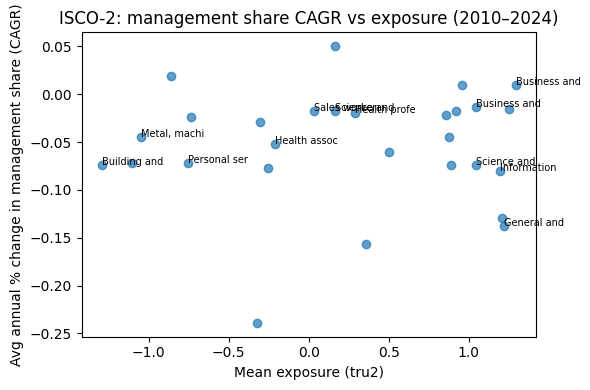

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_mgmt_share_vs_exposure_isco2.png
ISCO-2: management share CAGR vs exposure (2010–2024) Pearson: 0.034195008008553344
ISCO-2: management share CAGR vs exposure (2010–2024) Spearman: 0.06677613574165299


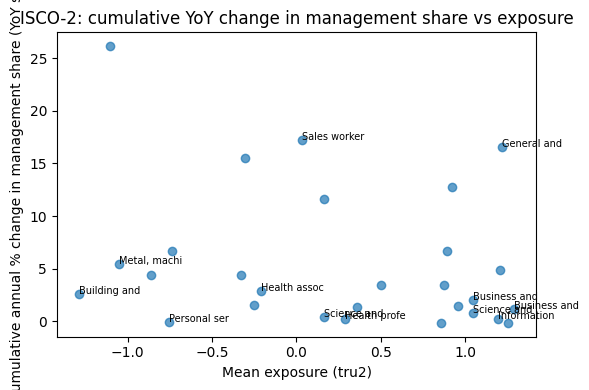

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_mgmt_share_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in management share vs exposure Pearson: -0.24853824915335965
ISCO-2: cumulative YoY change in management share vs exposure Spearman: -0.28407224958949095


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


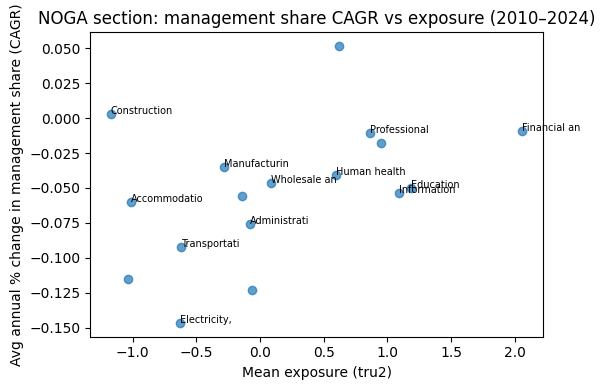

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_mgmt_share_vs_exposure_noga_section.png
NOGA section: management share CAGR vs exposure (2010–2024) Pearson: 0.44800513493856275
NOGA section: management share CAGR vs exposure (2010–2024) Spearman: 0.4264705882352941


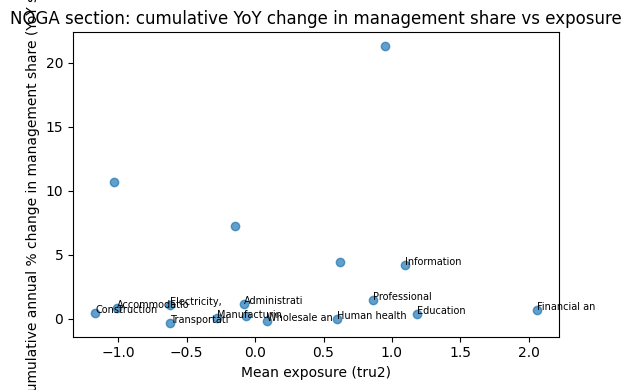

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_mgmt_share_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in management share vs exposure Pearson: 0.10849060228132223
NOGA section: cumulative YoY change in management share vs exposure Spearman: 0.09313725490196079


In [5]:
# --- Exposure impact: management share change vs exposure

mgmt_col = None
if 'vaca_posi_mana_clean' in df.columns:
    mgmt_col = 'vaca_posi_mana_clean'
elif 'vaca_posi_mana' in df.columns:
    mgmt_col = 'vaca_posi_mana'


def _group_management_share_series(df, group_col, mgmt_col):
    if mgmt_col is None or mgmt_col not in df.columns:
        return pd.DataFrame()
    tmp = df[[group_col, 'adve_time_year', WEIGHT, mgmt_col]].copy()
    if mgmt_col == 'vaca_posi_mana':
        tmp[mgmt_col] = tmp[mgmt_col].replace(-8, np.nan)
    tmp = tmp[tmp[mgmt_col].notna()]
    if tmp.empty:
        return pd.DataFrame()
    tmp['mgmt_weight'] = np.where(tmp[mgmt_col] == 1, tmp[WEIGHT], 0.0)
    grouped = tmp.groupby([group_col, 'adve_time_year'])
    share = grouped.agg(
        total_weight=(WEIGHT, 'sum'),
        mgmt_weight=('mgmt_weight', 'sum')
    ).reset_index()
    share['share_management'] = share['mgmt_weight'] / share['total_weight']
    return share[[group_col, 'adve_time_year', 'share_management']]


def _compute_mgmt_share_change_metrics(df, group_col, exp_col, mgmt_col, out_tag):
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    exp = _group_mean_exposure(df, group_col, exp_col)
    demand_series = _group_demand_series(df, group_col)
    last = demand_series[demand_series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    share_series = _group_management_share_series(df, group_col, mgmt_col)
    if share_series.empty:
        return pd.DataFrame()

    share_first = share_series[share_series['adve_time_year'] == y0].set_index(group_col)['share_management']
    share_last = share_series[share_series['adve_time_year'] == y1].set_index(group_col)['share_management']

    share_series = share_series.sort_values('adve_time_year')
    share_series['prev'] = share_series.groupby(group_col)['share_management'].shift(1)
    share_series['share_yoy'] = share_series['share_management'] / share_series['prev'] - 1
    share_series.loc[share_series['prev'] <= 0, 'share_yoy'] = np.nan
    share_series = share_series.replace([np.inf, -np.inf], np.nan)
    cum = share_series.groupby(group_col)['share_yoy'].sum().rename('cumulative_mgmt_share_yoy')

    out = pd.DataFrame({
        'mean_exposure': exp,
        'share_first': share_first,
        'share_last': share_last,
        'demand_last': last
    }).reset_index().rename(columns={group_col: 'group'})
    out = out.dropna(subset=['mean_exposure', 'share_first', 'share_last', 'demand_last'])
    out = out[(out['share_first'] > 0) & (out['share_last'] > 0)]

    out['mgmt_share_cagr'] = (out['share_last'] / out['share_first']) ** (1 / n_years) - 1

    out = out.merge(cum, left_on='group', right_index=True, how='left')
    out = out.dropna(subset=['cumulative_mgmt_share_yoy'])

    out.to_csv(OUT_TABLES / f'table_mgmt_share_change_metrics_{out_tag}.csv', index=False)
    return out


# Management share change vs exposure
if not mgmt_col:
    print('Skipping management share plots: management position column not found')
else:
    if 'occu_isco2_label' in df.columns:
        m_isco2_mgmt = _compute_mgmt_share_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', mgmt_col, 'isco2')
        _scatter_with_corr(
            m_isco2_mgmt, 'mean_exposure', 'mgmt_share_cagr',
            'ISCO-2: management share CAGR vs exposure (2010–2024)',
            'cagr_mgmt_share_vs_exposure_isco2',
            'Avg annual % change in management share (CAGR)'
        )
        _scatter_with_corr(
            m_isco2_mgmt, 'mean_exposure', 'cumulative_mgmt_share_yoy',
            'ISCO-2: cumulative YoY change in management share vs exposure',
            'cumyoy_mgmt_share_vs_exposure_isco2',
            'Cumulative annual % change in management share (YoY sum)'
        )

    if noga_label_col:
        m_noga_mgmt = _compute_mgmt_share_change_metrics(df, noga_label_col, 'industry_exposure_weighted', mgmt_col, 'noga_section')
        _scatter_with_corr(
            m_noga_mgmt, 'mean_exposure', 'mgmt_share_cagr',
            'NOGA section: management share CAGR vs exposure (2010–2024)',
            'cagr_mgmt_share_vs_exposure_noga_section',
            'Avg annual % change in management share (CAGR)'
        )
        _scatter_with_corr(
            m_noga_mgmt, 'mean_exposure', 'cumulative_mgmt_share_yoy',
            'NOGA section: cumulative YoY change in management share vs exposure',
            'cumyoy_mgmt_share_vs_exposure_noga_section',
            'Cumulative annual % change in management share (YoY sum)'
        )


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


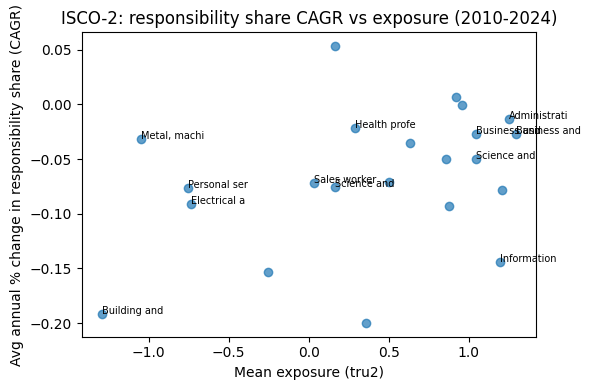

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_resp_share_vs_exposure_isco2.png
ISCO-2: responsibility share CAGR vs exposure (2010-2024) Pearson: 0.34238526408911213
ISCO-2: responsibility share CAGR vs exposure (2010-2024) Spearman: 0.339356295878035


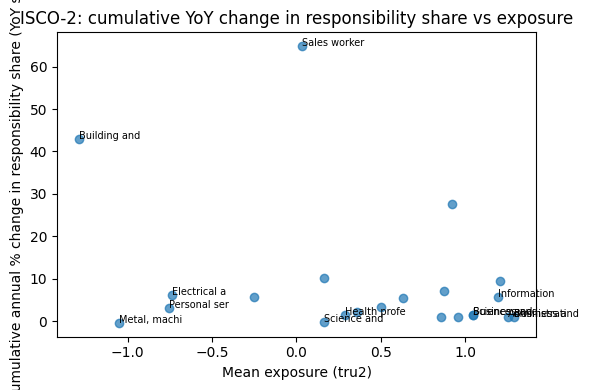

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_resp_share_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in responsibility share vs exposure Pearson: -0.2871087047200106
ISCO-2: cumulative YoY change in responsibility share vs exposure Spearman: -0.2140033879164314


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


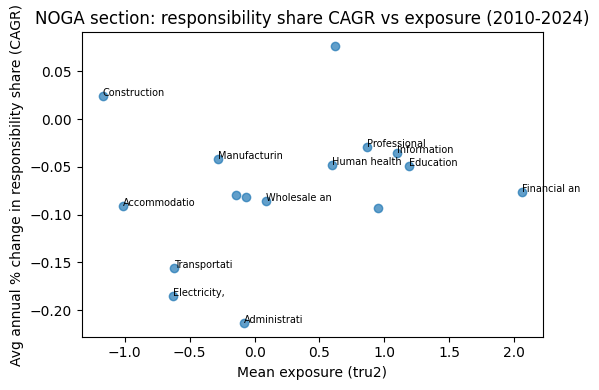

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_resp_share_vs_exposure_noga_section.png
NOGA section: responsibility share CAGR vs exposure (2010-2024) Pearson: 0.2266937496501766
NOGA section: responsibility share CAGR vs exposure (2010-2024) Spearman: 0.27647058823529413


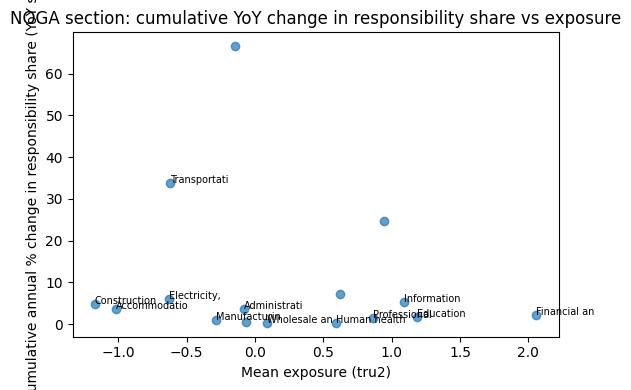

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_resp_share_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in responsibility share vs exposure Pearson: -0.15957739385505984
NOGA section: cumulative YoY change in responsibility share vs exposure Spearman: -0.19411764705882353


In [6]:
# --- Exposure impact: responsibility share change vs exposure

resp_col = None
if 'vaca_posi_resp_clean' in df.columns:
    resp_col = 'vaca_posi_resp_clean'
elif 'vaca_posi_resp' in df.columns:
    resp_col = 'vaca_posi_resp'


def _group_resp_share_series(df, group_col, resp_col):
    if resp_col is None or resp_col not in df.columns:
        return pd.DataFrame()
    tmp = df[[group_col, 'adve_time_year', WEIGHT, resp_col]].copy()
    if resp_col == 'vaca_posi_resp':
        tmp[resp_col] = tmp[resp_col].replace(-8, np.nan)
    tmp = tmp[tmp[resp_col].notna()]
    if tmp.empty:
        return pd.DataFrame()
    tmp['resp_weight'] = np.where(tmp[resp_col] == 1, tmp[WEIGHT], 0.0)
    grouped = tmp.groupby([group_col, 'adve_time_year'])
    share = grouped.agg(
        total_weight=(WEIGHT, 'sum'),
        resp_weight=('resp_weight', 'sum')
    ).reset_index()
    share['share_responsibility'] = share['resp_weight'] / share['total_weight']
    return share[[group_col, 'adve_time_year', 'share_responsibility']]


def _compute_resp_share_change_metrics(df, group_col, exp_col, resp_col, out_tag):
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    exp = _group_mean_exposure(df, group_col, exp_col)
    demand_series = _group_demand_series(df, group_col)
    last = demand_series[demand_series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    share_series = _group_resp_share_series(df, group_col, resp_col)
    if share_series.empty:
        return pd.DataFrame()

    share_first = share_series[share_series['adve_time_year'] == y0].set_index(group_col)['share_responsibility']
    share_last = share_series[share_series['adve_time_year'] == y1].set_index(group_col)['share_responsibility']

    share_series = share_series.sort_values('adve_time_year')
    share_series['prev'] = share_series.groupby(group_col)['share_responsibility'].shift(1)
    share_series['share_yoy'] = share_series['share_responsibility'] / share_series['prev'] - 1
    share_series.loc[share_series['prev'] <= 0, 'share_yoy'] = np.nan
    share_series = share_series.replace([np.inf, -np.inf], np.nan)
    cum = share_series.groupby(group_col)['share_yoy'].sum().rename('cumulative_resp_share_yoy')

    out = pd.DataFrame({
        'mean_exposure': exp,
        'share_first': share_first,
        'share_last': share_last,
        'demand_last': last
    }).reset_index().rename(columns={group_col: 'group'})
    out = out.dropna(subset=['mean_exposure', 'share_first', 'share_last', 'demand_last'])
    out = out[(out['share_first'] > 0) & (out['share_last'] > 0)]

    out['resp_share_cagr'] = (out['share_last'] / out['share_first']) ** (1 / n_years) - 1

    out = out.merge(cum, left_on='group', right_index=True, how='left')
    out = out.dropna(subset=['cumulative_resp_share_yoy'])

    out.to_csv(OUT_TABLES / f'table_resp_share_change_metrics_{out_tag}.csv', index=False)
    return out


# Responsibility share change vs exposure
if not resp_col:
    print('Skipping responsibility share plots: responsibility position column not found')
else:
    if 'occu_isco2_label' in df.columns:
        m_isco2_resp = _compute_resp_share_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', resp_col, 'isco2')
        _scatter_with_corr(
            m_isco2_resp, 'mean_exposure', 'resp_share_cagr',
            'ISCO-2: responsibility share CAGR vs exposure (2010-2024)',
            'cagr_resp_share_vs_exposure_isco2',
            'Avg annual % change in responsibility share (CAGR)'
        )
        _scatter_with_corr(
            m_isco2_resp, 'mean_exposure', 'cumulative_resp_share_yoy',
            'ISCO-2: cumulative YoY change in responsibility share vs exposure',
            'cumyoy_resp_share_vs_exposure_isco2',
            'Cumulative annual % change in responsibility share (YoY sum)'
        )

    if noga_label_col:
        m_noga_resp = _compute_resp_share_change_metrics(df, noga_label_col, 'industry_exposure_weighted', resp_col, 'noga_section')
        _scatter_with_corr(
            m_noga_resp, 'mean_exposure', 'resp_share_cagr',
            'NOGA section: responsibility share CAGR vs exposure (2010-2024)',
            'cagr_resp_share_vs_exposure_noga_section',
            'Avg annual % change in responsibility share (CAGR)'
        )
        _scatter_with_corr(
            m_noga_resp, 'mean_exposure', 'cumulative_resp_share_yoy',
            'NOGA section: cumulative YoY change in responsibility share vs exposure',
            'cumyoy_resp_share_vs_exposure_noga_section',
            'Cumulative annual % change in responsibility share (YoY sum)'
        )


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


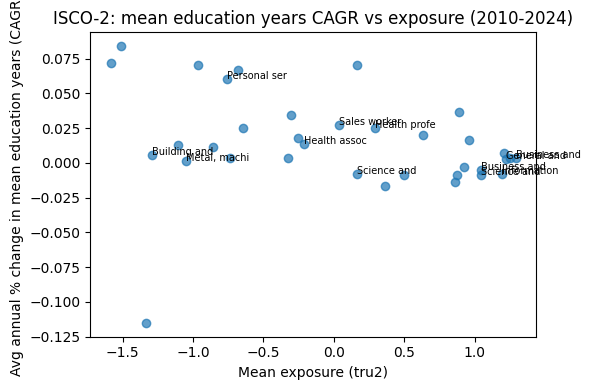

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_educ_yrsm_vs_exposure_isco2.png
ISCO-2: mean education years CAGR vs exposure (2010-2024) Pearson: -0.2572659347403827
ISCO-2: mean education years CAGR vs exposure (2010-2024) Spearman: -0.38487394957983195


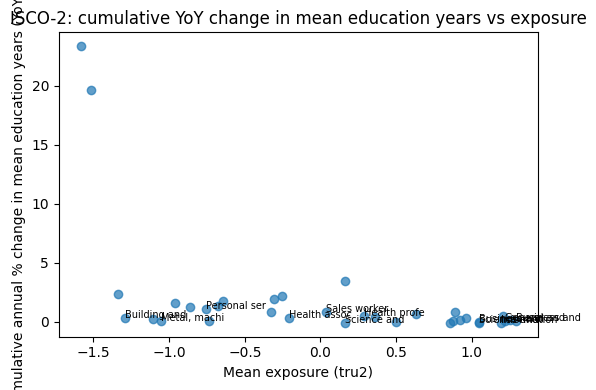

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_educ_yrsm_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in mean education years vs exposure Pearson: -0.4883867491538136
ISCO-2: cumulative YoY change in mean education years vs exposure Spearman: -0.565266106442577


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


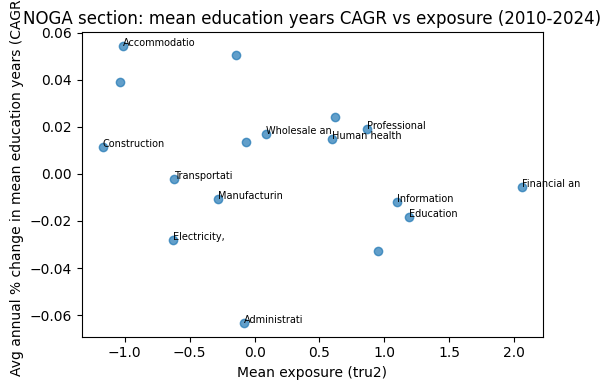

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_educ_yrsm_vs_exposure_noga_section.png
NOGA section: mean education years CAGR vs exposure (2010-2024) Pearson: -0.30409288578485993
NOGA section: mean education years CAGR vs exposure (2010-2024) Spearman: -0.30637254901960786


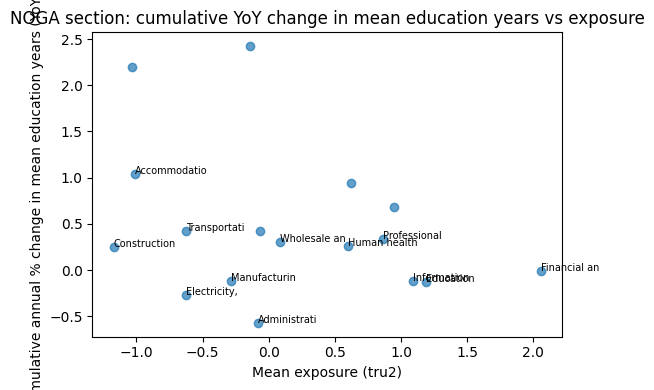

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_educ_yrsm_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in mean education years vs exposure Pearson: -0.3213650917650468
NOGA section: cumulative YoY change in mean education years vs exposure Spearman: -0.22549019607843138


In [7]:
# --- Exposure impact: education years change vs exposure

educ_col = 'incu_educ_yrsm' if 'incu_educ_yrsm' in df.columns else None


def _group_weighted_mean_series(df, group_col, value_col):
    if value_col is None or value_col not in df.columns:
        return pd.DataFrame()
    tmp = df[[group_col, 'adve_time_year', WEIGHT, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col].replace('NA', np.nan), errors='coerce')
    tmp = tmp[tmp[value_col].notna()]
    if tmp.empty:
        return pd.DataFrame()
    tmp['weighted_val'] = tmp[value_col] * tmp[WEIGHT]
    grouped = tmp.groupby([group_col, 'adve_time_year'])
    mean = grouped.agg(
        total_weight=(WEIGHT, 'sum'),
        weighted_val=('weighted_val', 'sum')
    ).reset_index()
    mean['value_mean'] = mean['weighted_val'] / mean['total_weight']
    return mean[[group_col, 'adve_time_year', 'value_mean']]


def _compute_educ_yrsm_change_metrics(df, group_col, exp_col, value_col, out_tag):
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    exp = _group_mean_exposure(df, group_col, exp_col)
    demand_series = _group_demand_series(df, group_col)
    last = demand_series[demand_series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    mean_series = _group_weighted_mean_series(df, group_col, value_col)
    if mean_series.empty:
        return pd.DataFrame()

    mean_first = mean_series[mean_series['adve_time_year'] == y0].set_index(group_col)['value_mean']
    mean_last = mean_series[mean_series['adve_time_year'] == y1].set_index(group_col)['value_mean']

    mean_series = mean_series.sort_values('adve_time_year')
    mean_series['prev'] = mean_series.groupby(group_col)['value_mean'].shift(1)
    mean_series['mean_yoy'] = mean_series['value_mean'] / mean_series['prev'] - 1
    mean_series.loc[mean_series['prev'] <= 0, 'mean_yoy'] = np.nan
    mean_series = mean_series.replace([np.inf, -np.inf], np.nan)
    cum = mean_series.groupby(group_col)['mean_yoy'].sum().rename('cumulative_educ_yrsm_yoy')

    out = pd.DataFrame({
        'mean_exposure': exp,
        'educ_yrsm_first': mean_first,
        'educ_yrsm_last': mean_last,
        'demand_last': last
    }).reset_index().rename(columns={group_col: 'group'})
    out = out.dropna(subset=['mean_exposure', 'educ_yrsm_first', 'educ_yrsm_last', 'demand_last'])
    out = out[(out['educ_yrsm_first'] > 0) & (out['educ_yrsm_last'] > 0)]

    out['educ_yrsm_cagr'] = (out['educ_yrsm_last'] / out['educ_yrsm_first']) ** (1 / n_years) - 1

    out = out.merge(cum, left_on='group', right_index=True, how='left')
    out = out.dropna(subset=['cumulative_educ_yrsm_yoy'])

    out.to_csv(OUT_TABLES / f'table_educ_yrsm_change_metrics_{out_tag}.csv', index=False)
    return out


# Education years change vs exposure
if not educ_col:
    print('Skipping education years plots: incu_educ_yrsm column not found')
else:
    if 'occu_isco2_label' in df.columns:
        m_isco2_educ = _compute_educ_yrsm_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', educ_col, 'isco2')
        _scatter_with_corr(
            m_isco2_educ, 'mean_exposure', 'educ_yrsm_cagr',
            'ISCO-2: mean education years CAGR vs exposure (2010-2024)',
            'cagr_educ_yrsm_vs_exposure_isco2',
            'Avg annual % change in mean education years (CAGR)'
        )
        _scatter_with_corr(
            m_isco2_educ, 'mean_exposure', 'cumulative_educ_yrsm_yoy',
            'ISCO-2: cumulative YoY change in mean education years vs exposure',
            'cumyoy_educ_yrsm_vs_exposure_isco2',
            'Cumulative annual % change in mean education years (YoY sum)'
        )

    if noga_label_col:
        m_noga_educ = _compute_educ_yrsm_change_metrics(df, noga_label_col, 'industry_exposure_weighted', educ_col, 'noga_section')
        _scatter_with_corr(
            m_noga_educ, 'mean_exposure', 'educ_yrsm_cagr',
            'NOGA section: mean education years CAGR vs exposure (2010-2024)',
            'cagr_educ_yrsm_vs_exposure_noga_section',
            'Avg annual % change in mean education years (CAGR)'
        )
        _scatter_with_corr(
            m_noga_educ, 'mean_exposure', 'cumulative_educ_yrsm_yoy',
            'NOGA section: cumulative YoY change in mean education years vs exposure',
            'cumyoy_educ_yrsm_vs_exposure_noga_section',
            'Cumulative annual % change in mean education years (YoY sum)'
        )


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


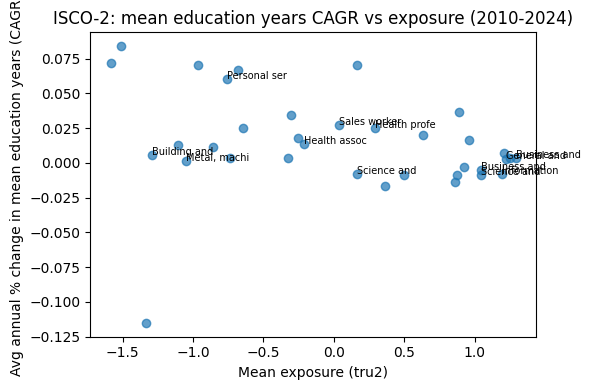

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_educ_yrsm_vs_exposure_isco2.png
ISCO-2: mean education years CAGR vs exposure (2010-2024) Pearson: -0.2572659347403827
ISCO-2: mean education years CAGR vs exposure (2010-2024) Spearman: -0.38487394957983195


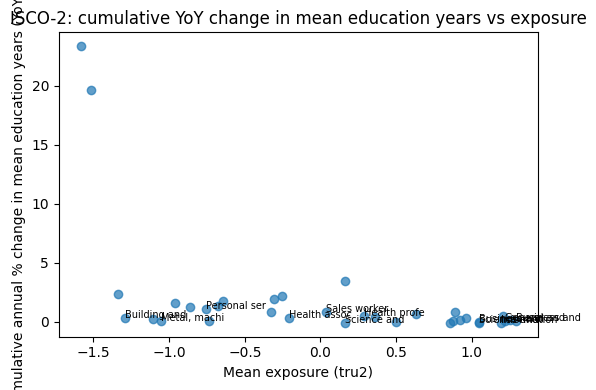

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_educ_yrsm_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in mean education years vs exposure Pearson: -0.4883867491538136
ISCO-2: cumulative YoY change in mean education years vs exposure Spearman: -0.565266106442577


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


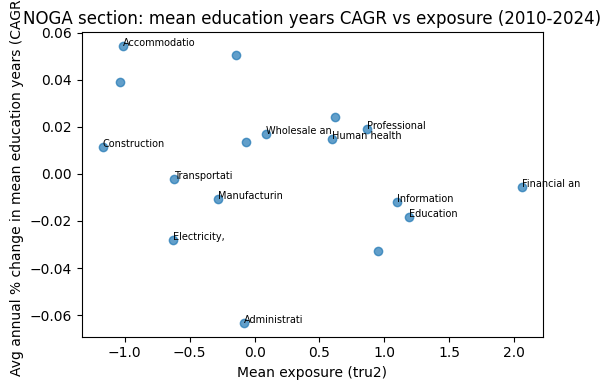

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_educ_yrsm_vs_exposure_noga_section.png
NOGA section: mean education years CAGR vs exposure (2010-2024) Pearson: -0.30409288578485993
NOGA section: mean education years CAGR vs exposure (2010-2024) Spearman: -0.30637254901960786


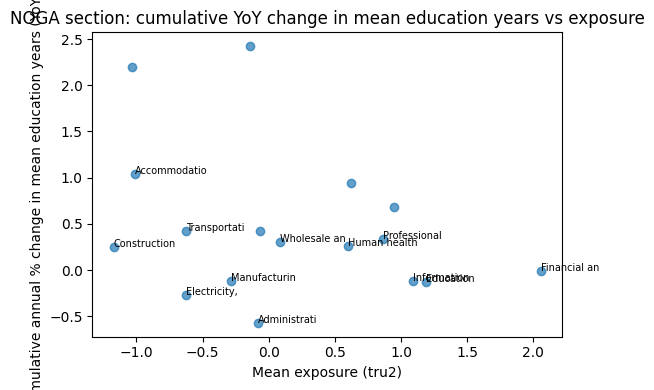

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_educ_yrsm_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in mean education years vs exposure Pearson: -0.3213650917650468
NOGA section: cumulative YoY change in mean education years vs exposure Spearman: -0.22549019607843138


In [ ]:
# --- Exposure impact: education years change vs exposure

educ_col = 'incu_educ_yrsm' if 'incu_educ_yrsm' in df.columns else None


def _group_weighted_mean_series(df, group_col, value_col):
    if value_col is None or value_col not in df.columns:
        return pd.DataFrame()
    tmp = df[[group_col, 'adve_time_year', WEIGHT, value_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col].replace('NA', np.nan), errors='coerce')
    tmp = tmp[tmp[value_col].notna()]
    if tmp.empty:
        return pd.DataFrame()
    tmp['weighted_val'] = tmp[value_col] * tmp[WEIGHT]
    grouped = tmp.groupby([group_col, 'adve_time_year'])
    mean = grouped.agg(
        total_weight=(WEIGHT, 'sum'),
        weighted_val=('weighted_val', 'sum')
    ).reset_index()
    mean['value_mean'] = mean['weighted_val'] / mean['total_weight']
    return mean[[group_col, 'adve_time_year', 'value_mean']]


def _compute_educ_yrsm_change_metrics(df, group_col, exp_col, value_col, out_tag):
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    exp = _group_mean_exposure(df, group_col, exp_col)
    demand_series = _group_demand_series(df, group_col)
    last = demand_series[demand_series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    mean_series = _group_weighted_mean_series(df, group_col, value_col)
    if mean_series.empty:
        return pd.DataFrame()

    mean_first = mean_series[mean_series['adve_time_year'] == y0].set_index(group_col)['value_mean']
    mean_last = mean_series[mean_series['adve_time_year'] == y1].set_index(group_col)['value_mean']

    mean_series = mean_series.sort_values('adve_time_year')
    mean_series['prev'] = mean_series.groupby(group_col)['value_mean'].shift(1)
    mean_series['mean_yoy'] = mean_series['value_mean'] / mean_series['prev'] - 1
    mean_series.loc[mean_series['prev'] <= 0, 'mean_yoy'] = np.nan
    mean_series = mean_series.replace([np.inf, -np.inf], np.nan)
    cum = mean_series.groupby(group_col)['mean_yoy'].sum().rename('cumulative_educ_yrsm_yoy')

    out = pd.DataFrame({
        'mean_exposure': exp,
        'educ_yrsm_first': mean_first,
        'educ_yrsm_last': mean_last,
        'demand_last': last
    }).reset_index().rename(columns={group_col: 'group'})
    out = out.dropna(subset=['mean_exposure', 'educ_yrsm_first', 'educ_yrsm_last', 'demand_last'])
    out = out[(out['educ_yrsm_first'] > 0) & (out['educ_yrsm_last'] > 0)]

    out['educ_yrsm_cagr'] = (out['educ_yrsm_last'] / out['educ_yrsm_first']) ** (1 / n_years) - 1

    out = out.merge(cum, left_on='group', right_index=True, how='left')
    out = out.dropna(subset=['cumulative_educ_yrsm_yoy'])

    out.to_csv(OUT_TABLES / f'table_educ_yrsm_change_metrics_{out_tag}.csv', index=False)
    return out


# Education years change vs exposure
if not educ_col:
    print('Skipping education years plots: incu_educ_yrsm column not found')
else:
    if 'occu_isco2_label' in df.columns:
        m_isco2_educ = _compute_educ_yrsm_change_metrics(df, 'occu_isco2_label', 'occupation_exposure', educ_col, 'isco2')
        _scatter_with_corr(
            m_isco2_educ, 'mean_exposure', 'educ_yrsm_cagr',
            'ISCO-2: mean education years CAGR vs exposure (2010-2024)',
            'cagr_educ_yrsm_vs_exposure_isco2',
            'Avg annual % change in mean education years (CAGR)'
        )
        _scatter_with_corr(
            m_isco2_educ, 'mean_exposure', 'cumulative_educ_yrsm_yoy',
            'ISCO-2: cumulative YoY change in mean education years vs exposure',
            'cumyoy_educ_yrsm_vs_exposure_isco2',
            'Cumulative annual % change in mean education years (YoY sum)'
        )

    if noga_label_col:
        m_noga_educ = _compute_educ_yrsm_change_metrics(df, noga_label_col, 'industry_exposure_weighted', educ_col, 'noga_section')
        _scatter_with_corr(
            m_noga_educ, 'mean_exposure', 'educ_yrsm_cagr',
            'NOGA section: mean education years CAGR vs exposure (2010-2024)',
            'cagr_educ_yrsm_vs_exposure_noga_section',
            'Avg annual % change in mean education years (CAGR)'
        )
        _scatter_with_corr(
            m_noga_educ, 'mean_exposure', 'cumulative_educ_yrsm_yoy',
            'NOGA section: cumulative YoY change in mean education years vs exposure',
            'cumyoy_educ_yrsm_vs_exposure_noga_section',
            'Cumulative annual % change in mean education years (YoY sum)'
        )


In [8]:
# --- Skill data: load social (soski) and ICT skill counts per posting
import json as _json
import bz2 as _bz2

SKILL_BASE = ROOT / 'Base Dataset' / 'Data' / '699_SJMM_Data_TextualData_v10.0' / 'sjmm_suf_standoff'
SOSKI_DIR = SKILL_BASE / 'soski-de'
ICT_DIR = SKILL_BASE / 'ict-de'

YEARS = sorted(df['adve_time_year'].dropna().astype(int).unique())
YEARS = [y for y in YEARS if 2010 <= y <= 2024]
ADVE_IDS = set(df['adve_iden_adve'].dropna().unique())

FILL_MISSING_SKILLS_WITH_ZERO = True


def _find_year_file(folder, prefix, year):
    for suffix in ['.jsonl.bz2', '.jsonl']:
        path = folder / f'{prefix}-{year}{suffix}'
        if path.exists():
            return path
    return None


def _iter_jsonl(path):
    opener = _bz2.open if path.suffix == '.bz2' else open
    with opener(path, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield _json.loads(line)


def _load_skill_counts(folder, prefix, years, id_set, out_col):
    rows = []
    for y in years:
        path = _find_year_file(folder, prefix, y)
        if path is None:
            print(f'Missing {prefix} file for {y}')
            continue
        for obj in _iter_jsonl(path):
            adve = obj.get('adve_iden_adve')
            if adve in id_set:
                spans = obj.get('spans') or []
                rows.append({'adve_iden_adve': adve, out_col: len(spans)})
    return pd.DataFrame(rows)


soski_counts = _load_skill_counts(SOSKI_DIR, 'soski-catg-de', YEARS, ADVE_IDS, 'soski_count')
ict_counts = _load_skill_counts(ICT_DIR, 'ict-catg-de', YEARS, ADVE_IDS, 'ict_count')

skill_cols = ['adve_iden_adve', 'adve_time_year', WEIGHT, 'occupation_exposure', 'industry_exposure_weighted', 'occu_isco2_label']
if noga_label_col and noga_label_col in df.columns:
    skill_cols.append(noga_label_col)
if 'ai_requirement' in df.columns:
    skill_cols.append('ai_requirement')

df_skill = df[skill_cols].copy()
df_skill = df_skill.merge(soski_counts, on='adve_iden_adve', how='left')
df_skill = df_skill.merge(ict_counts, on='adve_iden_adve', how='left')

if FILL_MISSING_SKILLS_WITH_ZERO:
    df_skill['soski_count'] = df_skill['soski_count'].fillna(0)
    df_skill['ict_count'] = df_skill['ict_count'].fillna(0)


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


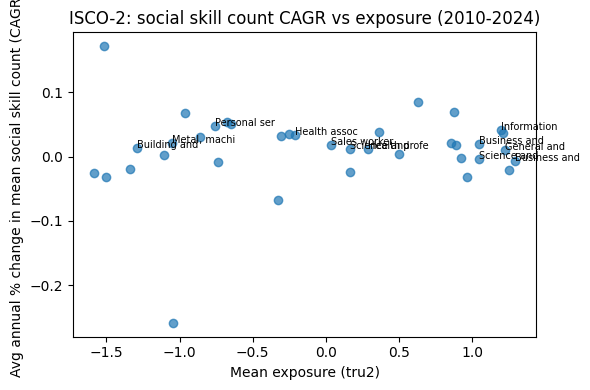

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_soski_count_vs_exposure_isco2.png
ISCO-2: social skill count CAGR vs exposure (2010-2024) Pearson: 0.05835134679720397
ISCO-2: social skill count CAGR vs exposure (2010-2024) Spearman: 0.00734945471787577


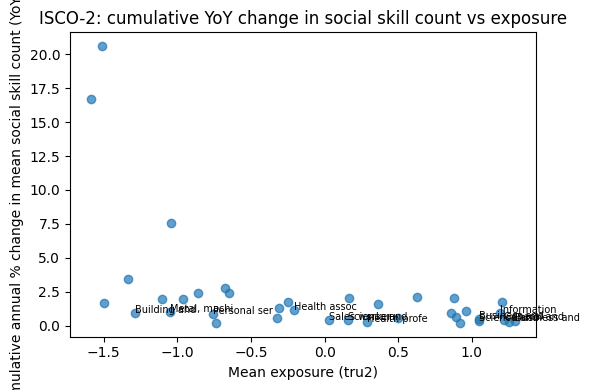

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_soski_count_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in social skill count vs exposure Pearson: -0.4940672188844245
ISCO-2: cumulative YoY change in social skill count vs exposure Spearman: -0.5637743006164059


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


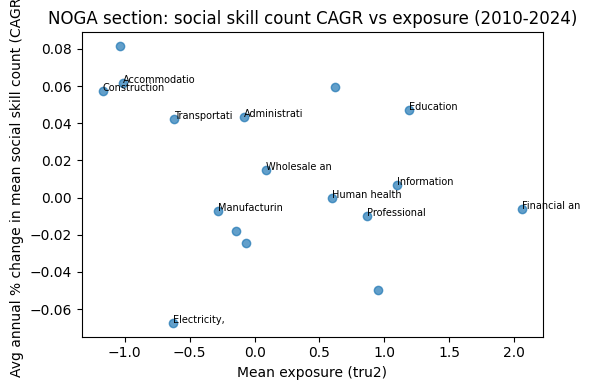

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_soski_count_vs_exposure_noga_section.png
NOGA section: social skill count CAGR vs exposure (2010-2024) Pearson: -0.3180793561517381
NOGA section: social skill count CAGR vs exposure (2010-2024) Spearman: -0.27450980392156865


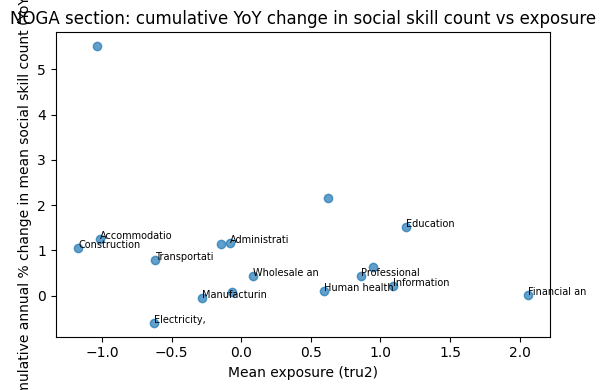

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_soski_count_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in social skill count vs exposure Pearson: -0.3186194671947266
NOGA section: cumulative YoY change in social skill count vs exposure Spearman: -0.17647058823529413


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


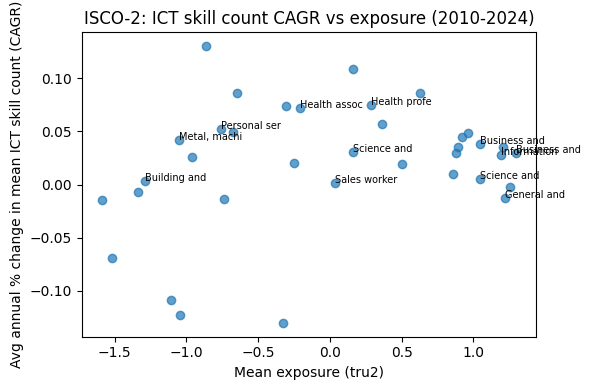

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_ict_count_vs_exposure_isco2.png
ISCO-2: ICT skill count CAGR vs exposure (2010-2024) Pearson: 0.2647941613883069
ISCO-2: ICT skill count CAGR vs exposure (2010-2024) Spearman: 0.20566280566280568


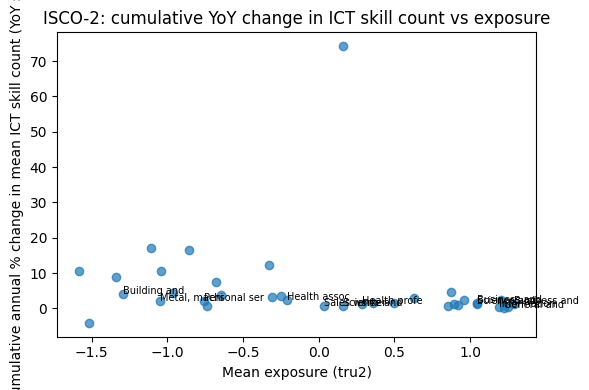

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_ict_count_vs_exposure_isco2.png
ISCO-2: cumulative YoY change in ICT skill count vs exposure Pearson: -0.15000124293575914
ISCO-2: cumulative YoY change in ICT skill count vs exposure Spearman: -0.5232947232947233


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


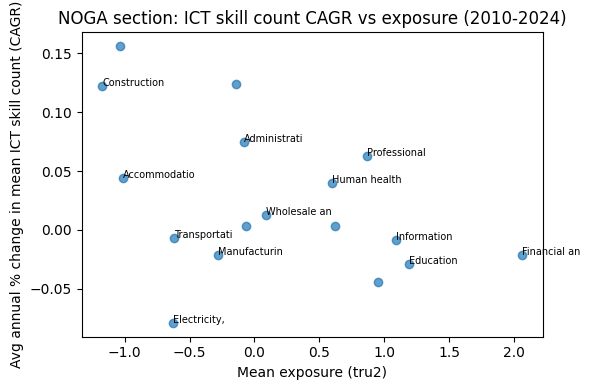

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_ict_count_vs_exposure_noga_section.png
NOGA section: ICT skill count CAGR vs exposure (2010-2024) Pearson: -0.44954663036703857
NOGA section: ICT skill count CAGR vs exposure (2010-2024) Spearman: -0.4852941176470588


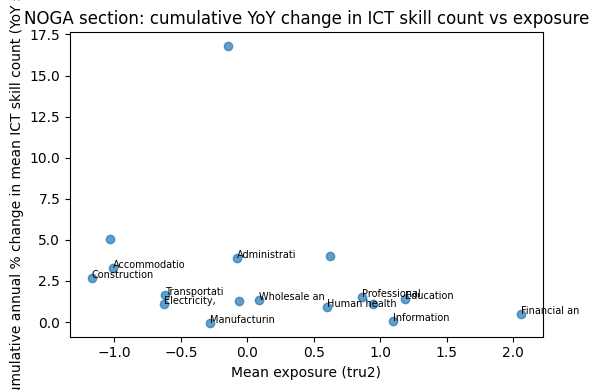

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_ict_count_vs_exposure_noga_section.png
NOGA section: cumulative YoY change in ICT skill count vs exposure Pearson: -0.2566000462407047
NOGA section: cumulative YoY change in ICT skill count vs exposure Spearman: -0.45588235294117646


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/2357459970.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  share = grouped.apply(


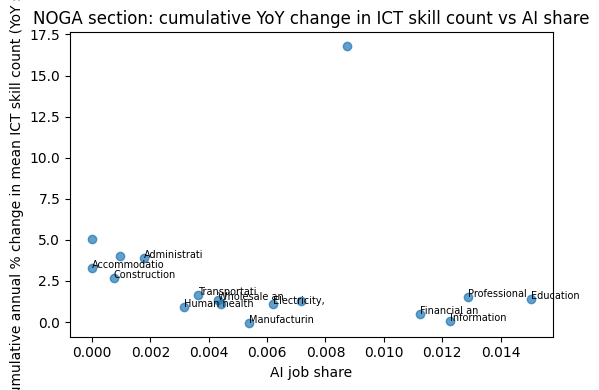

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_ict_count_vs_ai_share_noga_section.png
NOGA section: cumulative YoY change in ICT skill count vs AI share Pearson: -0.08614005027306108
NOGA section: cumulative YoY change in ICT skill count vs AI share Spearman: -0.4696506094275222


In [9]:
# --- Skill change vs exposure: social and ICT skill counts

AI_SHARE_INCLUDE_MAYBE = False

if '_group_weighted_mean_series' not in globals():
    def _group_weighted_mean_series(df, group_col, value_col):
        if value_col is None or value_col not in df.columns:
            return pd.DataFrame()
        tmp = df[[group_col, 'adve_time_year', WEIGHT, value_col]].copy()
        tmp[value_col] = pd.to_numeric(tmp[value_col], errors='coerce')
        tmp = tmp[tmp[value_col].notna()]
        if tmp.empty:
            return pd.DataFrame()
        tmp['weighted_val'] = tmp[value_col] * tmp[WEIGHT]
        grouped = tmp.groupby([group_col, 'adve_time_year'])
        mean = grouped.agg(
            total_weight=(WEIGHT, 'sum'),
            weighted_val=('weighted_val', 'sum')
        ).reset_index()
        mean['value_mean'] = mean['weighted_val'] / mean['total_weight']
        return mean[[group_col, 'adve_time_year', 'value_mean']]


def _group_ai_share(df, group_col, ai_col):
    if ai_col is None or ai_col not in df.columns:
        return pd.Series(dtype=float)
    tmp = df[[group_col, WEIGHT, ai_col]].copy()
    tmp = tmp[tmp[ai_col].notna()]
    if tmp.empty:
        return pd.Series(dtype=float)
    if AI_SHARE_INCLUDE_MAYBE:
        tmp['ai_flag'] = tmp[ai_col].isin(['True', 'Maybe'])
    else:
        tmp['ai_flag'] = tmp[ai_col] == 'True'
    grouped = tmp.groupby(group_col)
    share = grouped.apply(
        lambda g: g.loc[g['ai_flag'], WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan
    )
    return share.rename('ai_share')


def _scatter_with_corr_x(df, x_col, y_col, label, out_tag, y_label, x_label):
    tmp = df.dropna(subset=[x_col, y_col])
    if tmp.empty:
        print(f"Skipping {out_tag}: no data")
        return
    plt.figure(figsize=(6,4))
    plt.scatter(tmp[x_col], tmp[y_col], alpha=0.7)
    for _, row in tmp.nlargest(12, 'demand_last').iterrows():
        plt.text(row[x_col], row[y_col], str(row['group'])[:12], fontsize=7)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(label)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_{out_tag}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    pearson = tmp[[x_col, y_col]].corr().iloc[0,1]
    spearman = tmp[[x_col, y_col]].corr(method='spearman').iloc[0,1]
    print(f"{label} Pearson:", pearson)
    print(f"{label} Spearman:", spearman)


def _compute_skill_count_change_metrics(df, group_col, exp_col, value_col, out_tag, metric_prefix):
    years = df['adve_time_year'].dropna().astype(int)
    if years.empty:
        return pd.DataFrame()
    y0 = years.min()
    y1 = years.max()
    n_years = y1 - y0
    if n_years <= 0:
        return pd.DataFrame()

    exp = _group_mean_exposure(df, group_col, exp_col)
    demand_series = _group_demand_series(df, group_col)
    last = demand_series[demand_series['adve_time_year'] == y1].set_index(group_col)[WEIGHT]

    mean_series = _group_weighted_mean_series(df, group_col, value_col)
    if mean_series.empty:
        return pd.DataFrame()

    mean_first = mean_series[mean_series['adve_time_year'] == y0].set_index(group_col)['value_mean']
    mean_last = mean_series[mean_series['adve_time_year'] == y1].set_index(group_col)['value_mean']

    mean_series = mean_series.sort_values('adve_time_year')
    mean_series['prev'] = mean_series.groupby(group_col)['value_mean'].shift(1)
    mean_series['mean_yoy'] = mean_series['value_mean'] / mean_series['prev'] - 1
    mean_series.loc[mean_series['prev'] <= 0, 'mean_yoy'] = np.nan
    mean_series = mean_series.replace([np.inf, -np.inf], np.nan)
    cum = mean_series.groupby(group_col)['mean_yoy'].sum().rename(f'cumulative_{metric_prefix}_yoy')

    out = pd.DataFrame({
        'mean_exposure': exp,
        f'{metric_prefix}_first': mean_first,
        f'{metric_prefix}_last': mean_last,
        'demand_last': last
    }).reset_index().rename(columns={group_col: 'group'})
    out = out.dropna(subset=['mean_exposure', f'{metric_prefix}_first', f'{metric_prefix}_last', 'demand_last'])
    out = out[(out[f'{metric_prefix}_first'] > 0) & (out[f'{metric_prefix}_last'] > 0)]

    out[f'{metric_prefix}_cagr'] = (out[f'{metric_prefix}_last'] / out[f'{metric_prefix}_first']) ** (1 / n_years) - 1

    out = out.merge(cum, left_on='group', right_index=True, how='left')
    out = out.dropna(subset=[f'cumulative_{metric_prefix}_yoy'])

    out.to_csv(OUT_TABLES / f'table_{metric_prefix}_change_metrics_{out_tag}.csv', index=False)
    return out


# Social skills (soski) count change vs exposure
if 'occu_isco2_label' in df_skill.columns:
    m_isco2_soski = _compute_skill_count_change_metrics(
        df_skill, 'occu_isco2_label', 'occupation_exposure', 'soski_count',
        'isco2', 'soski_count'
    )
    _scatter_with_corr(
        m_isco2_soski, 'mean_exposure', 'soski_count_cagr',
        'ISCO-2: social skill count CAGR vs exposure (2010-2024)',
        'cagr_soski_count_vs_exposure_isco2',
        'Avg annual % change in mean social skill count (CAGR)'
    )
    _scatter_with_corr(
        m_isco2_soski, 'mean_exposure', 'cumulative_soski_count_yoy',
        'ISCO-2: cumulative YoY change in social skill count vs exposure',
        'cumyoy_soski_count_vs_exposure_isco2',
        'Cumulative annual % change in mean social skill count (YoY sum)'
    )

if noga_label_col and noga_label_col in df_skill.columns:
    m_noga_soski = _compute_skill_count_change_metrics(
        df_skill, noga_label_col, 'industry_exposure_weighted', 'soski_count',
        'noga_section', 'soski_count'
    )
    _scatter_with_corr(
        m_noga_soski, 'mean_exposure', 'soski_count_cagr',
        'NOGA section: social skill count CAGR vs exposure (2010-2024)',
        'cagr_soski_count_vs_exposure_noga_section',
        'Avg annual % change in mean social skill count (CAGR)'
    )
    _scatter_with_corr(
        m_noga_soski, 'mean_exposure', 'cumulative_soski_count_yoy',
        'NOGA section: cumulative YoY change in social skill count vs exposure',
        'cumyoy_soski_count_vs_exposure_noga_section',
        'Cumulative annual % change in mean social skill count (YoY sum)'
    )

# ICT skills count change vs exposure
if 'occu_isco2_label' in df_skill.columns:
    m_isco2_ict = _compute_skill_count_change_metrics(
        df_skill, 'occu_isco2_label', 'occupation_exposure', 'ict_count',
        'isco2', 'ict_count'
    )
    _scatter_with_corr(
        m_isco2_ict, 'mean_exposure', 'ict_count_cagr',
        'ISCO-2: ICT skill count CAGR vs exposure (2010-2024)',
        'cagr_ict_count_vs_exposure_isco2',
        'Avg annual % change in mean ICT skill count (CAGR)'
    )
    _scatter_with_corr(
        m_isco2_ict, 'mean_exposure', 'cumulative_ict_count_yoy',
        'ISCO-2: cumulative YoY change in ICT skill count vs exposure',
        'cumyoy_ict_count_vs_exposure_isco2',
        'Cumulative annual % change in mean ICT skill count (YoY sum)'
    )

if noga_label_col and noga_label_col in df_skill.columns:
    m_noga_ict = _compute_skill_count_change_metrics(
        df_skill, noga_label_col, 'industry_exposure_weighted', 'ict_count',
        'noga_section', 'ict_count'
    )
    _scatter_with_corr(
        m_noga_ict, 'mean_exposure', 'ict_count_cagr',
        'NOGA section: ICT skill count CAGR vs exposure (2010-2024)',
        'cagr_ict_count_vs_exposure_noga_section',
        'Avg annual % change in mean ICT skill count (CAGR)'
    )
    _scatter_with_corr(
        m_noga_ict, 'mean_exposure', 'cumulative_ict_count_yoy',
        'NOGA section: cumulative YoY change in ICT skill count vs exposure',
        'cumyoy_ict_count_vs_exposure_noga_section',
        'Cumulative annual % change in mean ICT skill count (YoY sum)'
    )

    if 'ai_requirement' in df_skill.columns:
        ai_share_noga = _group_ai_share(df_skill, noga_label_col, 'ai_requirement')
        if not ai_share_noga.empty:
            m_noga_ict_ai = m_noga_ict.merge(ai_share_noga, left_on='group', right_index=True, how='left')
            _scatter_with_corr_x(
                m_noga_ict_ai, 'ai_share', 'cumulative_ict_count_yoy',
                'NOGA section: cumulative YoY change in ICT skill count vs AI share',
                'cumyoy_ict_count_vs_ai_share_noga_section',
                'Cumulative annual % change in mean ICT skill count (YoY sum)',
                'AI job share'
            )
        else:
            print('Skipping AI share plot: ai share not available for NOGA groups')
    else:
        print('Skipping AI share plot: ai_requirement column not found')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/2357459970.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  share = grouped.apply(
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


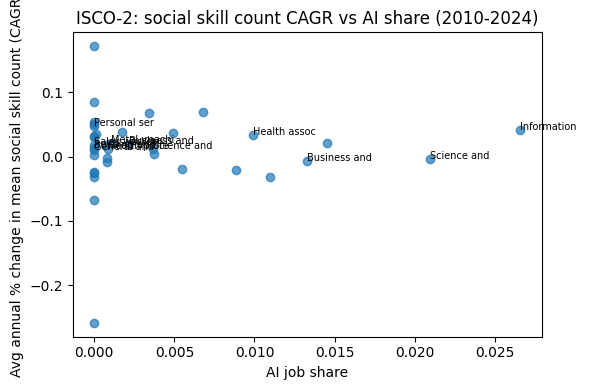

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_soski_count_vs_ai_share_isco2.png
ISCO-2: social skill count CAGR vs AI share (2010-2024) Pearson: 0.023067719174815617
ISCO-2: social skill count CAGR vs AI share (2010-2024) Spearman: -0.013722580686780188


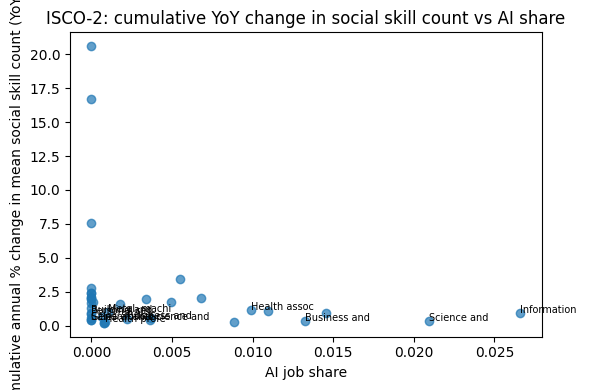

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_soski_count_vs_ai_share_isco2.png
ISCO-2: cumulative YoY change in social skill count vs AI share Pearson: -0.20353529158529046
ISCO-2: cumulative YoY change in social skill count vs AI share Spearman: -0.3782981702842106


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


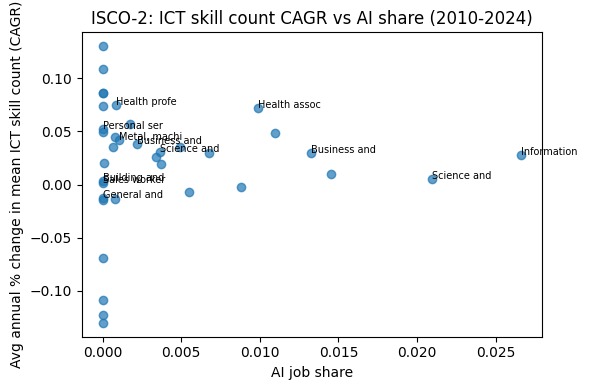

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_ict_count_vs_ai_share_isco2.png
ISCO-2: ICT skill count CAGR vs AI share (2010-2024) Pearson: 0.04572919549427423
ISCO-2: ICT skill count CAGR vs AI share (2010-2024) Spearman: 0.0034737231761836577


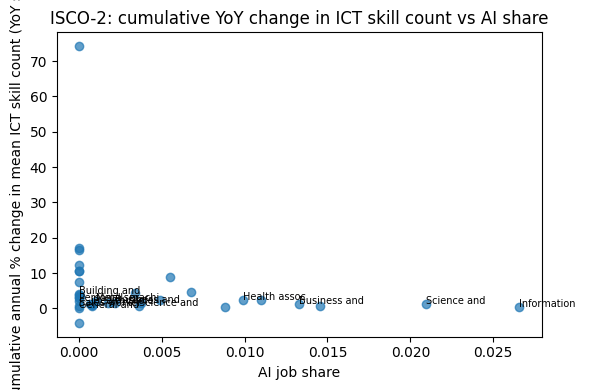

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_ict_count_vs_ai_share_isco2.png
ISCO-2: cumulative YoY change in ICT skill count vs AI share Pearson: -0.19778508195643404
ISCO-2: cumulative YoY change in ICT skill count vs AI share Spearman: -0.38371280623074866


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/2357459970.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  share = grouped.apply(
/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


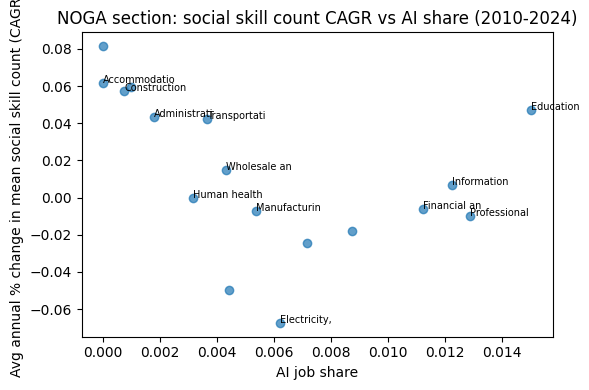

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_soski_count_vs_ai_share_noga_section.png
NOGA section: social skill count CAGR vs AI share (2010-2024) Pearson: -0.41892427900389884
NOGA section: social skill count CAGR vs AI share (2010-2024) Spearman: -0.6118946582358579


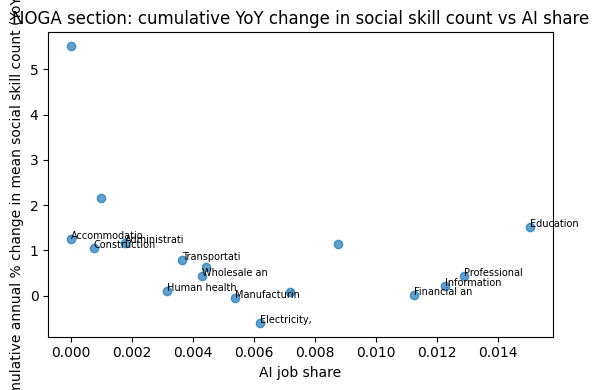

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_soski_count_vs_ai_share_noga_section.png
NOGA section: cumulative YoY change in social skill count vs AI share Pearson: -0.39022459133003834
NOGA section: cumulative YoY change in social skill count vs AI share Spearman: -0.445125773426085


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


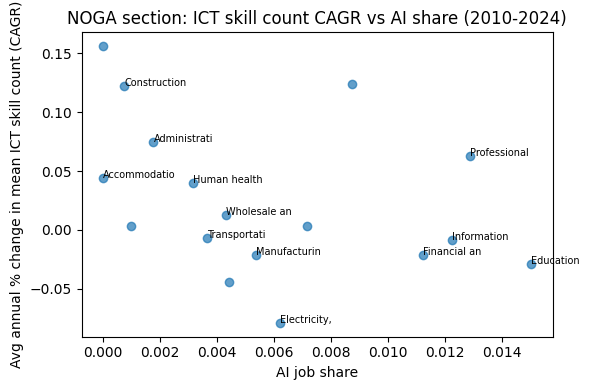

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cagr_ict_count_vs_ai_share_noga_section.png
NOGA section: ICT skill count CAGR vs AI share (2010-2024) Pearson: -0.35783976073007817
NOGA section: ICT skill count CAGR vs AI share (2010-2024) Spearman: -0.4696506094275222


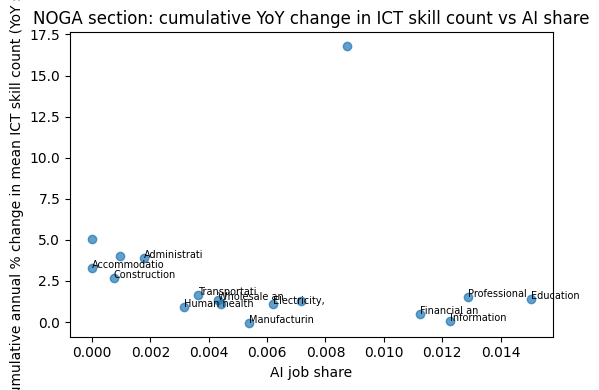

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_cumyoy_ict_count_vs_ai_share_noga_section.png
NOGA section: cumulative YoY change in ICT skill count vs AI share Pearson: -0.08614005027306108
NOGA section: cumulative YoY change in ICT skill count vs AI share Spearman: -0.4696506094275222


In [10]:
# --- Skill change vs AI share: social and ICT skill counts

AI_SHARE_INCLUDE_MAYBE = False

if '_group_ai_share' not in globals():
    def _group_ai_share(df, group_col, ai_col):
        if ai_col is None or ai_col not in df.columns:
            return pd.Series(dtype=float)
        tmp = df[[group_col, WEIGHT, ai_col]].copy()
        tmp = tmp[tmp[ai_col].notna()]
        if tmp.empty:
            return pd.Series(dtype=float)
        if AI_SHARE_INCLUDE_MAYBE:
            tmp['ai_flag'] = tmp[ai_col].isin(['True', 'Maybe'])
        else:
            tmp['ai_flag'] = tmp[ai_col] == 'True'
        grouped = tmp.groupby(group_col)
        share = grouped.apply(
            lambda g: g.loc[g['ai_flag'], WEIGHT].sum() / g[WEIGHT].sum() if g[WEIGHT].sum() else np.nan
        )
        return share.rename('ai_share')


if '_scatter_with_corr_x' not in globals():
    def _scatter_with_corr_x(df, x_col, y_col, label, out_tag, y_label, x_label):
        tmp = df.dropna(subset=[x_col, y_col])
        if tmp.empty:
            print(f"Skipping {out_tag}: no data")
            return
        plt.figure(figsize=(6,4))
        plt.scatter(tmp[x_col], tmp[y_col], alpha=0.7)
        for _, row in tmp.nlargest(12, 'demand_last').iterrows():
            plt.text(row[x_col], row[y_col], str(row['group'])[:12], fontsize=7)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(label)
        plt.tight_layout()
        fig_path = OUT_VIS / f'fig_{out_tag}.png'
        plt.savefig(fig_path, dpi=150)
        plt.show()
        print('Saved', fig_path)

        pearson = tmp[[x_col, y_col]].corr().iloc[0,1]
        spearman = tmp[[x_col, y_col]].corr(method='spearman').iloc[0,1]
        print(f"{label} Pearson:", pearson)
        print(f"{label} Spearman:", spearman)


if 'ai_requirement' not in df_skill.columns:
    print('Skipping AI share plots: ai_requirement column not found')
else:
    if 'occu_isco2_label' in df_skill.columns:
        ai_share_isco2 = _group_ai_share(df_skill, 'occu_isco2_label', 'ai_requirement')
        if not ai_share_isco2.empty:
            m_isco2_soski = _compute_skill_count_change_metrics(
                df_skill, 'occu_isco2_label', 'occupation_exposure', 'soski_count',
                'isco2', 'soski_count'
            )
            m_isco2_soski_ai = m_isco2_soski.merge(ai_share_isco2, left_on='group', right_index=True, how='left')
            _scatter_with_corr_x(
                m_isco2_soski_ai, 'ai_share', 'soski_count_cagr',
                'ISCO-2: social skill count CAGR vs AI share (2010-2024)',
                'cagr_soski_count_vs_ai_share_isco2',
                'Avg annual % change in mean social skill count (CAGR)',
                'AI job share'
            )
            _scatter_with_corr_x(
                m_isco2_soski_ai, 'ai_share', 'cumulative_soski_count_yoy',
                'ISCO-2: cumulative YoY change in social skill count vs AI share',
                'cumyoy_soski_count_vs_ai_share_isco2',
                'Cumulative annual % change in mean social skill count (YoY sum)',
                'AI job share'
            )

            m_isco2_ict = _compute_skill_count_change_metrics(
                df_skill, 'occu_isco2_label', 'occupation_exposure', 'ict_count',
                'isco2', 'ict_count'
            )
            m_isco2_ict_ai = m_isco2_ict.merge(ai_share_isco2, left_on='group', right_index=True, how='left')
            _scatter_with_corr_x(
                m_isco2_ict_ai, 'ai_share', 'ict_count_cagr',
                'ISCO-2: ICT skill count CAGR vs AI share (2010-2024)',
                'cagr_ict_count_vs_ai_share_isco2',
                'Avg annual % change in mean ICT skill count (CAGR)',
                'AI job share'
            )
            _scatter_with_corr_x(
                m_isco2_ict_ai, 'ai_share', 'cumulative_ict_count_yoy',
                'ISCO-2: cumulative YoY change in ICT skill count vs AI share',
                'cumyoy_ict_count_vs_ai_share_isco2',
                'Cumulative annual % change in mean ICT skill count (YoY sum)',
                'AI job share'
            )
        else:
            print('Skipping ISCO-2 AI share plots: no ai share data')

    if noga_label_col and noga_label_col in df_skill.columns:
        ai_share_noga = _group_ai_share(df_skill, noga_label_col, 'ai_requirement')
        if not ai_share_noga.empty:
            m_noga_soski = _compute_skill_count_change_metrics(
                df_skill, noga_label_col, 'industry_exposure_weighted', 'soski_count',
                'noga_section', 'soski_count'
            )
            m_noga_soski_ai = m_noga_soski.merge(ai_share_noga, left_on='group', right_index=True, how='left')
            _scatter_with_corr_x(
                m_noga_soski_ai, 'ai_share', 'soski_count_cagr',
                'NOGA section: social skill count CAGR vs AI share (2010-2024)',
                'cagr_soski_count_vs_ai_share_noga_section',
                'Avg annual % change in mean social skill count (CAGR)',
                'AI job share'
            )
            _scatter_with_corr_x(
                m_noga_soski_ai, 'ai_share', 'cumulative_soski_count_yoy',
                'NOGA section: cumulative YoY change in social skill count vs AI share',
                'cumyoy_soski_count_vs_ai_share_noga_section',
                'Cumulative annual % change in mean social skill count (YoY sum)',
                'AI job share'
            )

            m_noga_ict = _compute_skill_count_change_metrics(
                df_skill, noga_label_col, 'industry_exposure_weighted', 'ict_count',
                'noga_section', 'ict_count'
            )
            m_noga_ict_ai = m_noga_ict.merge(ai_share_noga, left_on='group', right_index=True, how='left')
            _scatter_with_corr_x(
                m_noga_ict_ai, 'ai_share', 'ict_count_cagr',
                'NOGA section: ICT skill count CAGR vs AI share (2010-2024)',
                'cagr_ict_count_vs_ai_share_noga_section',
                'Avg annual % change in mean ICT skill count (CAGR)',
                'AI job share'
            )
            _scatter_with_corr_x(
                m_noga_ict_ai, 'ai_share', 'cumulative_ict_count_yoy',
                'NOGA section: cumulative YoY change in ICT skill count vs AI share',
                'cumyoy_ict_count_vs_ai_share_noga_section',
                'Cumulative annual % change in mean ICT skill count (YoY sum)',
                'AI job share'
            )
        else:
            print('Skipping NOGA AI share plots: no ai share data')


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


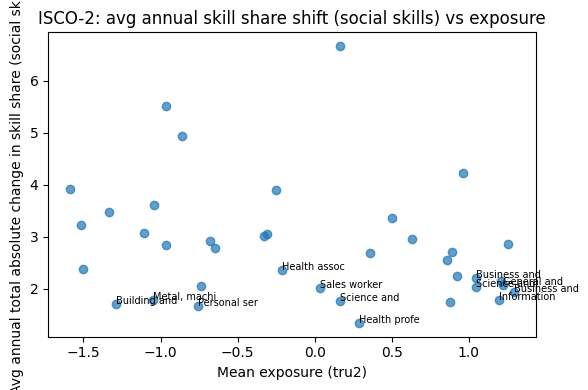

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_isco2_avg_share_shift.png
ISCO-2: avg annual skill share shift (social skills) vs exposure Pearson: -0.25625797074758017
ISCO-2: avg annual skill share shift (social skills) vs exposure Spearman: -0.3093336251230988


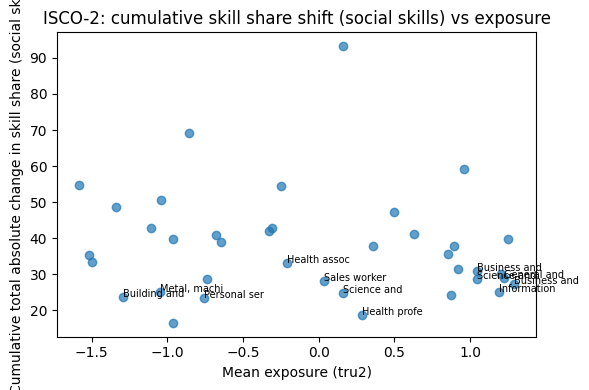

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_isco2_cum_share_shift.png
ISCO-2: cumulative skill share shift (social skills) vs exposure Pearson: -0.1392712362372522
ISCO-2: cumulative skill share shift (social skills) vs exposure Spearman: -0.18131086552139183


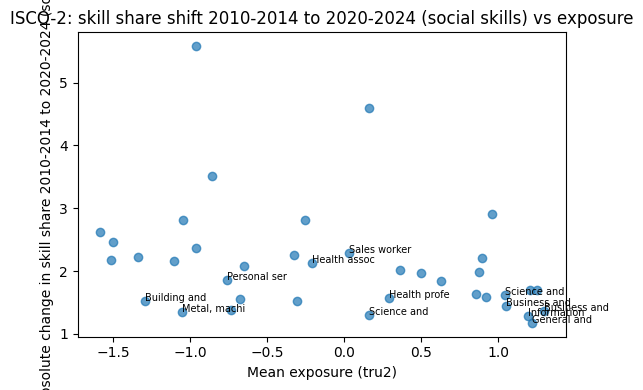

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_isco2_period_share_shift.png
ISCO-2: skill share shift 2010-2014 to 2020-2024 (social skills) vs exposure Pearson: -0.32422927104819343
ISCO-2: skill share shift 2010-2014 to 2020-2024 (social skills) vs exposure Spearman: -0.41853594485173434


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


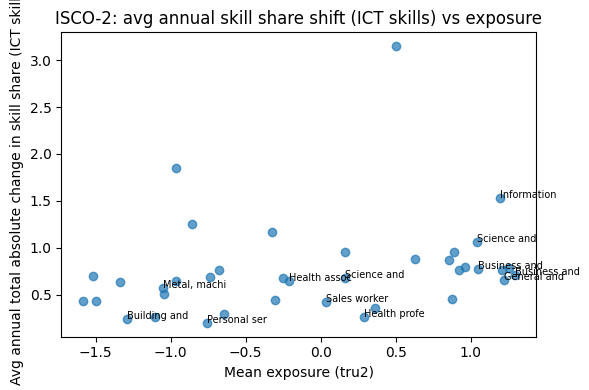

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_isco2_avg_share_shift.png
ISCO-2: avg annual skill share shift (ICT skills) vs exposure Pearson: 0.24400834279219263
ISCO-2: avg annual skill share shift (ICT skills) vs exposure Spearman: 0.43538680380785644


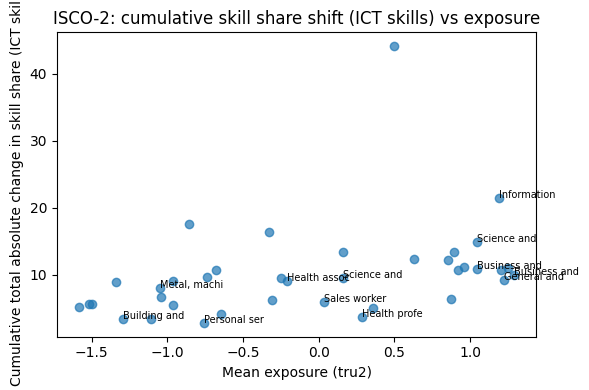

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_isco2_cum_share_shift.png
ISCO-2: cumulative skill share shift (ICT skills) vs exposure Pearson: 0.36524525286048487
ISCO-2: cumulative skill share shift (ICT skills) vs exposure Spearman: 0.5607834555202976


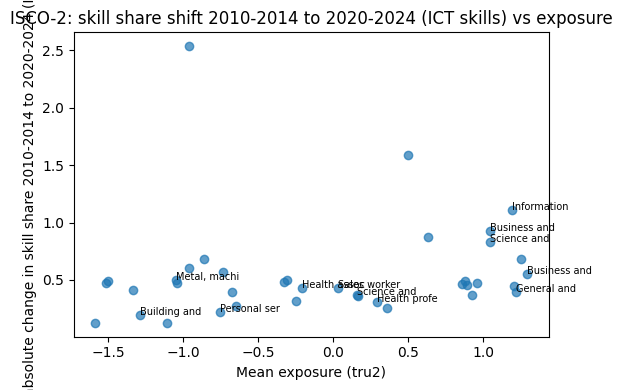

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_isco2_period_share_shift.png
ISCO-2: skill share shift 2010-2014 to 2020-2024 (ICT skills) vs exposure Pearson: 0.1298409344676303
ISCO-2: skill share shift 2010-2014 to 2020-2024 (ICT skills) vs exposure Spearman: 0.2839479155268629


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


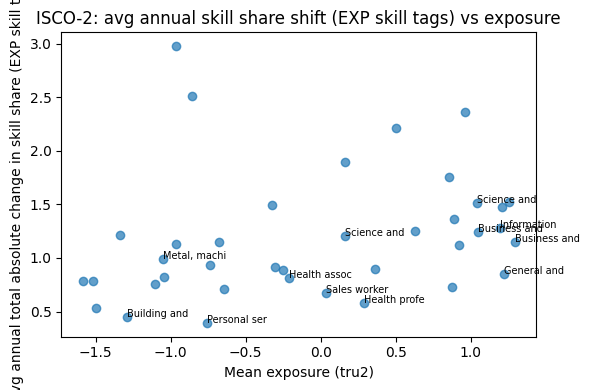

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_isco2_avg_share_shift.png
ISCO-2: avg annual skill share shift (EXP skill tags) vs exposure Pearson: 0.251929339921887
ISCO-2: avg annual skill share shift (EXP skill tags) vs exposure Spearman: 0.4159098369624685


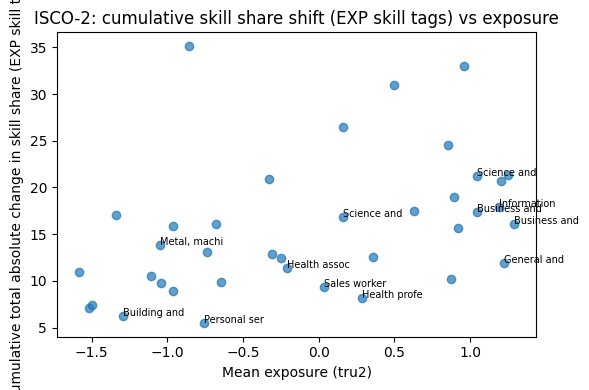

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_isco2_cum_share_shift.png
ISCO-2: cumulative skill share shift (EXP skill tags) vs exposure Pearson: 0.4289499763027174
ISCO-2: cumulative skill share shift (EXP skill tags) vs exposure Spearman: 0.5275194222562644


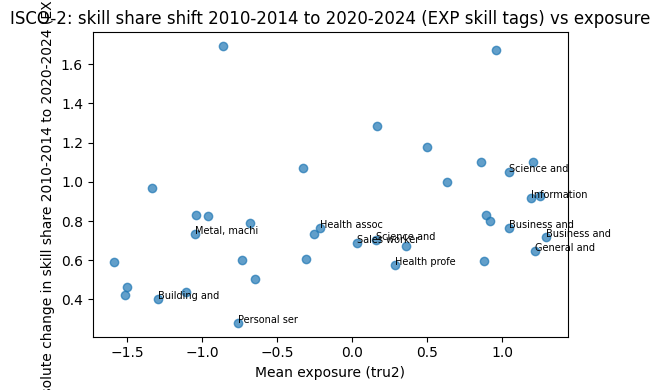

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_isco2_period_share_shift.png
ISCO-2: skill share shift 2010-2014 to 2020-2024 (EXP skill tags) vs exposure Pearson: 0.36201135445995763
ISCO-2: skill share shift 2010-2014 to 2020-2024 (EXP skill tags) vs exposure Spearman: 0.42555713608345186


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


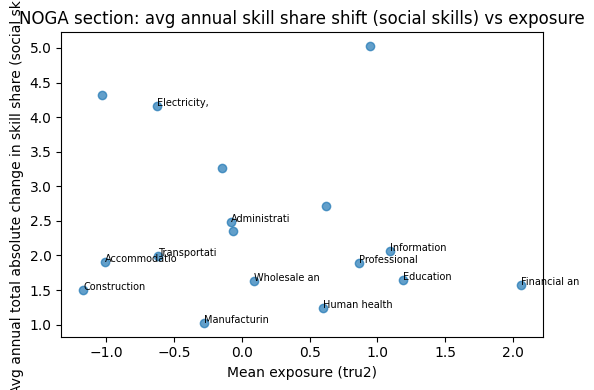

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_noga_section_avg_share_shift.png
NOGA section: avg annual skill share shift (social skills) vs exposure Pearson: -0.14783724591774922
NOGA section: avg annual skill share shift (social skills) vs exposure Spearman: -0.1053921568627451


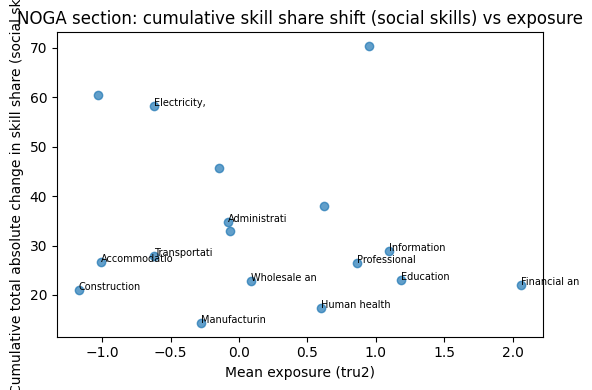

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_noga_section_cum_share_shift.png
NOGA section: cumulative skill share shift (social skills) vs exposure Pearson: -0.14783724591774908
NOGA section: cumulative skill share shift (social skills) vs exposure Spearman: -0.1053921568627451


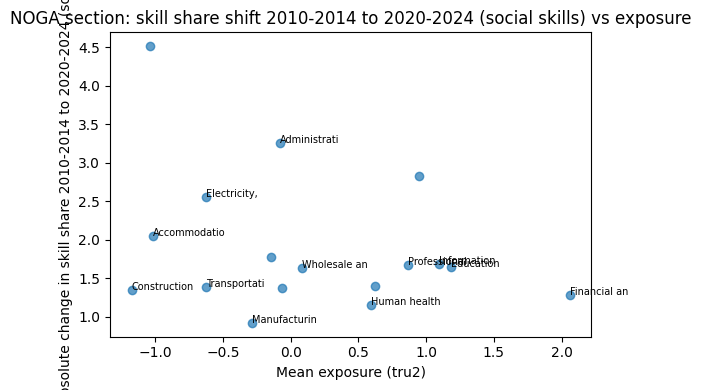

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_soski_noga_section_period_share_shift.png
NOGA section: skill share shift 2010-2014 to 2020-2024 (social skills) vs exposure Pearson: -0.30335297001237654
NOGA section: skill share shift 2010-2014 to 2020-2024 (social skills) vs exposure Spearman: -0.15931372549019607


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


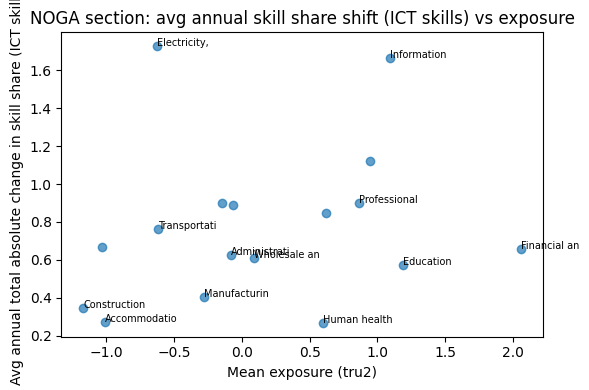

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_noga_section_avg_share_shift.png
NOGA section: avg annual skill share shift (ICT skills) vs exposure Pearson: 0.20802675430887266
NOGA section: avg annual skill share shift (ICT skills) vs exposure Spearman: 0.24019607843137256


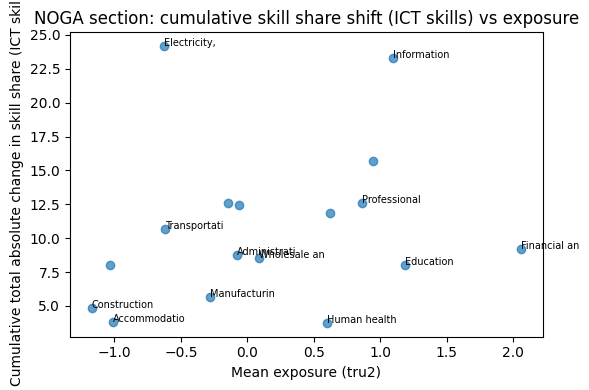

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_noga_section_cum_share_shift.png
NOGA section: cumulative skill share shift (ICT skills) vs exposure Pearson: 0.22515423468473617
NOGA section: cumulative skill share shift (ICT skills) vs exposure Spearman: 0.34558823529411764


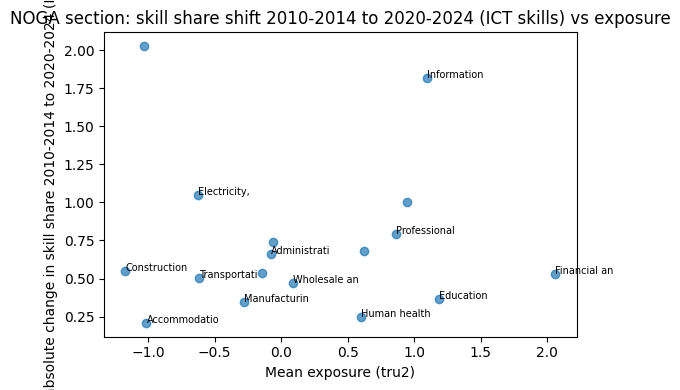

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_ict_noga_section_period_share_shift.png
NOGA section: skill share shift 2010-2014 to 2020-2024 (ICT skills) vs exposure Pearson: -0.029367819394416367
NOGA section: skill share shift 2010-2014 to 2020-2024 (ICT skills) vs exposure Spearman: 0.031862745098039214


/var/folders/b8/xcnlw57x6_3gqylzftwx02tr0000gn/T/ipykernel_9185/3582685018.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g[exp_col].dropna(), weights=g.loc[g[exp_col].notna(), WEIGHT])


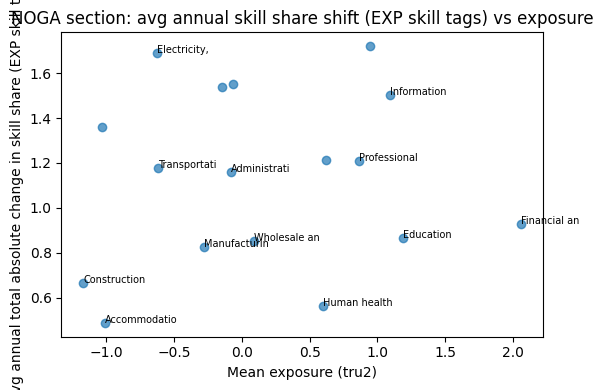

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_noga_section_avg_share_shift.png
NOGA section: avg annual skill share shift (EXP skill tags) vs exposure Pearson: 0.09759257730802451
NOGA section: avg annual skill share shift (EXP skill tags) vs exposure Spearman: 0.15931372549019607


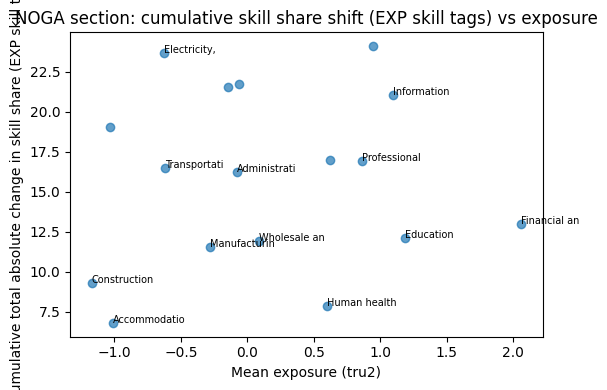

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_noga_section_cum_share_shift.png
NOGA section: cumulative skill share shift (EXP skill tags) vs exposure Pearson: 0.09759257730802455
NOGA section: cumulative skill share shift (EXP skill tags) vs exposure Spearman: 0.15931372549019607


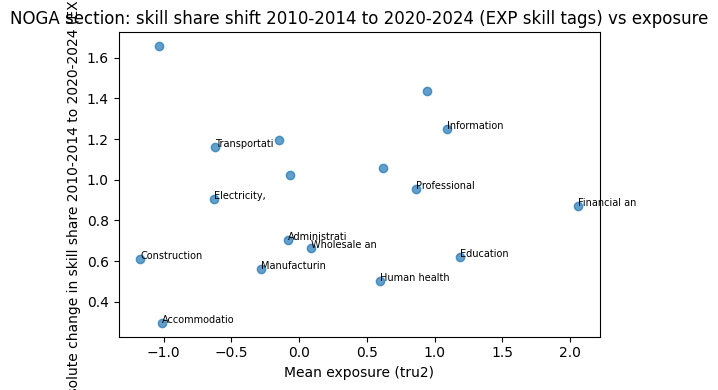

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase4_exposure_impact/visuals/fig_allskills_exp_noga_section_period_share_shift.png
NOGA section: skill share shift 2010-2014 to 2020-2024 (EXP skill tags) vs exposure Pearson: 0.08049525026267862
NOGA section: skill share shift 2010-2014 to 2020-2024 (EXP skill tags) vs exposure Spearman: 0.13970588235294118


In [12]:
# --- All-skill frequency shift vs exposure (social, ICT, EXP)
import json as _json
import bz2 as _bz2
from collections import defaultdict

YEARS = sorted(df['adve_time_year'].dropna().astype(int).unique())
YEARS = [y for y in YEARS if 2010 <= y <= 2024]

if 'df_skill' not in globals():
    skill_cols = ['adve_iden_adve', 'adve_time_year', WEIGHT, 'occupation_exposure', 'industry_exposure_weighted', 'occu_isco2_label']
    if noga_label_col and noga_label_col in df.columns:
        skill_cols.append(noga_label_col)
    df_skill = df[skill_cols].copy()

ADVE_IDS = set(df_skill['adve_iden_adve'].dropna().unique())

if 'SKILL_BASE' not in globals():
    SKILL_BASE = ROOT / 'Base Dataset' / 'Data' / '699_SJMM_Data_TextualData_v10.0' / 'sjmm_suf_standoff'
if 'SOSKI_DIR' not in globals():
    SOSKI_DIR = SKILL_BASE / 'soski-de'
if 'ICT_DIR' not in globals():
    ICT_DIR = SKILL_BASE / 'ict-de'
EXP_DIR = SKILL_BASE / 'edu_exp_lng-de'

if '_find_year_file' not in globals():
    def _find_year_file(folder, prefix, year):
        for suffix in ['.jsonl.bz2', '.jsonl']:
            path = folder / f'{prefix}-{year}{suffix}'
            if path.exists():
                return path
        return None

if '_iter_jsonl' not in globals():
    def _iter_jsonl(path):
        opener = _bz2.open if path.suffix == '.bz2' else open
        with opener(path, 'rt', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                yield _json.loads(line)

if '_period_label' not in globals():
    PERIODS = [(2010, 2014, '2010-2014'), (2015, 2019, '2015-2019'), (2020, 2024, '2020-2024')]
    def _period_label(y):
        for a, b, lbl in PERIODS:
            if a <= y <= b:
                return lbl
        return None


def _best_label_from_mappings(mappings, target_ontology=None, allow_fallback=False):
    if mappings:
        for mapping in mappings:
            if target_ontology and mapping.get('ontology') != target_ontology:
                continue
            classes = mapping.get('classes') or []
            if classes:
                best = max(classes, key=lambda c: c.get('score', 0))
                return best.get('label')
    if allow_fallback and mappings:
        for mapping in mappings:
            classes = mapping.get('classes') or []
            if classes:
                best = max(classes, key=lambda c: c.get('score', 0))
                return best.get('label')
    return None


def _extract_soski_l2(obj):
    cats = set()
    for span in obj.get('spans', []) or []:
        label = _best_label_from_mappings(span.get('mappings', []), 'skillprofiler-L2')
        if label:
            cats.add(label)
    return cats


def _extract_ict_l2(obj):
    cats = set()
    for span in obj.get('spans', []) or []:
        label = _best_label_from_mappings(span.get('mappings', []), 'onetSMM-L2')
        if label:
            cats.add(label)
    return cats


def _extract_exp_skill(obj):
    cats = set()
    for span in obj.get('spans', []) or []:
        if span.get('label') != 'EXP':
            continue
        for sub in span.get('subspans', []) or []:
            if sub.get('label') not in ('SKILL', 'SkillContainer'):
                continue
            label = _best_label_from_mappings(sub.get('mappings', []), 'ESCO', allow_fallback=True)
            if label:
                cats.add(label)
    return cats


def _collect_categories(folder, prefix, years, id_set, extractor, family_tag):
    ad_to_cats = defaultdict(set)
    for y in years:
        path = _find_year_file(folder, prefix, y)
        if path is None:
            print(f'Missing {family_tag} file for {y}')
            continue
        print(f'Loading {family_tag} {y}...')
        for obj in _iter_jsonl(path):
            adve = obj.get('adve_iden_adve')
            if adve not in id_set:
                continue
            cats = extractor(obj)
            if cats:
                ad_to_cats[adve].update(cats)
    rows = [{'adve_iden_adve': adve, 'category': cat} for adve, cats in ad_to_cats.items() for cat in cats]
    return pd.DataFrame(rows)


def _compute_category_shares(mentions_df, group_col):
    base = df_skill[[group_col, 'adve_time_year', WEIGHT, 'adve_iden_adve']].dropna(subset=[group_col, 'adve_time_year'])
    base['adve_time_year'] = base['adve_time_year'].astype(int)
    total = base.groupby([group_col, 'adve_time_year'])[WEIGHT].sum().rename('total_weight').reset_index()

    mention = mentions_df.merge(base, on='adve_iden_adve', how='inner')
    mention_weight = (
        mention.groupby([group_col, 'adve_time_year', 'category'])[WEIGHT]
               .sum()
               .rename('mention_weight')
               .reset_index()
    )
    mention_weight = mention_weight.merge(total, on=[group_col, 'adve_time_year'], how='left')
    mention_weight['share'] = mention_weight['mention_weight'] / mention_weight['total_weight']
    return mention_weight


def _yearly_share_shift(share_df, group_col):
    rows = []
    for grp, g in share_df.groupby(group_col):
        years = sorted(g['adve_time_year'].unique())
        share_by_year = {}
        for y in years:
            s = g[g['adve_time_year'] == y].set_index('category')['share']
            share_by_year[y] = s
        prev_year = None
        for y in years:
            if prev_year is None:
                prev_year = y
                continue
            prev = share_by_year.get(prev_year, pd.Series(dtype=float))
            curr = share_by_year.get(y, pd.Series(dtype=float))
            all_cats = prev.index.union(curr.index)
            diff = (prev.reindex(all_cats, fill_value=0) - curr.reindex(all_cats, fill_value=0)).abs().sum()
            rows.append({'group': grp, 'adve_time_year': y, 'share_shift': diff})
            prev_year = y
    return pd.DataFrame(rows)


def _period_share_shift(share_df, group_col):
    period_keep = {'2010-2014', '2020-2024'}
    base = df_skill[[group_col, 'adve_time_year', WEIGHT]].dropna(subset=[group_col, 'adve_time_year'])
    base['period'] = base['adve_time_year'].map(_period_label)
    base = base[base['period'].isin(period_keep)]
    total = base.groupby([group_col, 'period'])[WEIGHT].sum().rename('total_weight').reset_index()

    tmp = share_df.copy()
    tmp['period'] = tmp['adve_time_year'].map(_period_label)
    tmp = tmp[tmp['period'].isin(period_keep)]
    mention_period = (
        tmp.groupby([group_col, 'period', 'category'])['mention_weight']
           .sum()
           .rename('mention_weight')
           .reset_index()
    )
    mention_period = mention_period.merge(total, on=[group_col, 'period'], how='left')
    mention_period['share'] = mention_period['mention_weight'] / mention_period['total_weight']

    out = {}
    for grp, g in mention_period.groupby(group_col):
        period_sets = {}
        for period, gp in g.groupby('period'):
            period_sets[period] = gp.set_index('category')['share']
        if '2010-2014' in period_sets and '2020-2024' in period_sets:
            prev = period_sets['2010-2014']
            curr = period_sets['2020-2024']
            all_cats = prev.index.union(curr.index)
            diff = (prev.reindex(all_cats, fill_value=0) - curr.reindex(all_cats, fill_value=0)).abs().sum()
            out[grp] = diff
    return pd.Series(out, name='period_share_shift_2010_2014_to_2020_2024')


def _compute_share_shift_metrics(mentions_df, group_col, exp_col, family_tag, group_tag):
    share_df = _compute_category_shares(mentions_df, group_col)
    yearly = _yearly_share_shift(share_df, group_col)

    metrics = (
        yearly.groupby('group')['share_shift']
              .agg(avg_share_shift='mean', cumulative_share_shift='sum')
              .reset_index()
    )

    period = _period_share_shift(share_df, group_col).reset_index().rename(columns={'index': 'group'})
    metrics = metrics.merge(period, on='group', how='left')

    exp = _group_mean_exposure(df_skill, group_col, exp_col)
    demand_series = _group_demand_series(df_skill, group_col)
    last_year = max(YEARS) if YEARS else None
    demand_last = demand_series[demand_series['adve_time_year'] == last_year].set_index(group_col)[WEIGHT]

    out = metrics.merge(exp, left_on='group', right_index=True, how='left')
    out = out.merge(demand_last.rename('demand_last'), left_on='group', right_index=True, how='left')
    out = out.dropna(subset=['mean_exposure'])

    out.to_csv(OUT_TABLES / f'table_allskills_share_shift_{family_tag}_{group_tag}.csv', index=False)
    return out


def _plot_share_shift(out, family_label, group_label, out_prefix):
    _scatter_with_corr(
        out, 'mean_exposure', 'avg_share_shift',
        f'{group_label}: avg annual skill share shift ({family_label}) vs exposure',
        f'{out_prefix}_avg_share_shift',
        f'Avg annual total absolute change in skill share ({family_label})'
    )
    _scatter_with_corr(
        out, 'mean_exposure', 'cumulative_share_shift',
        f'{group_label}: cumulative skill share shift ({family_label}) vs exposure',
        f'{out_prefix}_cum_share_shift',
        f'Cumulative total absolute change in skill share ({family_label})'
    )
    _scatter_with_corr(
        out, 'mean_exposure', 'period_share_shift_2010_2014_to_2020_2024',
        f'{group_label}: skill share shift 2010-2014 to 2020-2024 ({family_label}) vs exposure',
        f'{out_prefix}_period_share_shift',
        f'Total absolute change in skill share 2010-2014 to 2020-2024 ({family_label})'
    )


# Build category mentions
if 'soski_mentions' not in globals():
    soski_mentions = _collect_categories(SOSKI_DIR, 'soski-catg-de', YEARS, ADVE_IDS, _extract_soski_l2, 'soski')
if 'ict_mentions' not in globals():
    ict_mentions = _collect_categories(ICT_DIR, 'ict-catg-de', YEARS, ADVE_IDS, _extract_ict_l2, 'ict')
if 'exp_mentions' not in globals():
    exp_mentions = _collect_categories(EXP_DIR, 'edu_exp_lng-catg-de', YEARS, ADVE_IDS, _extract_exp_skill, 'exp')

# ISCO-2 plots
if 'occu_isco2_label' in df_skill.columns:
    out_soski_isco2 = _compute_share_shift_metrics(soski_mentions, 'occu_isco2_label', 'occupation_exposure', 'soski', 'isco2')
    _plot_share_shift(out_soski_isco2, 'social skills', 'ISCO-2', 'allskills_soski_isco2')

    out_ict_isco2 = _compute_share_shift_metrics(ict_mentions, 'occu_isco2_label', 'occupation_exposure', 'ict', 'isco2')
    _plot_share_shift(out_ict_isco2, 'ICT skills', 'ISCO-2', 'allskills_ict_isco2')

    out_exp_isco2 = _compute_share_shift_metrics(exp_mentions, 'occu_isco2_label', 'occupation_exposure', 'exp', 'isco2')
    _plot_share_shift(out_exp_isco2, 'EXP skill tags', 'ISCO-2', 'allskills_exp_isco2')

# NOGA section plots
if noga_label_col and noga_label_col in df_skill.columns:
    out_soski_noga = _compute_share_shift_metrics(soski_mentions, noga_label_col, 'industry_exposure_weighted', 'soski', 'noga_section')
    _plot_share_shift(out_soski_noga, 'social skills', 'NOGA section', 'allskills_soski_noga_section')

    out_ict_noga = _compute_share_shift_metrics(ict_mentions, noga_label_col, 'industry_exposure_weighted', 'ict', 'noga_section')
    _plot_share_shift(out_ict_noga, 'ICT skills', 'NOGA section', 'allskills_ict_noga_section')

    out_exp_noga = _compute_share_shift_metrics(exp_mentions, noga_label_col, 'industry_exposure_weighted', 'exp', 'noga_section')
    _plot_share_shift(out_exp_noga, 'EXP skill tags', 'NOGA section', 'allskills_exp_noga_section')
